# **Initial Setup and Library Imports**

In [44]:
!pip install prophet -q

In [45]:
# Core Libraries
import os
import glob
import math
import locale
import itertools
import warnings
import datetime
import urllib.request

import numpy as np
import pandas as pd

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

import seaborn as sns

from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

from pandas.plotting import lag_plot

# Scientific & Statistics
from scipy import stats
from scipy.stats import pearsonr
from scipy.interpolate import make_interp_spline

# Time Series Analysis
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, zivot_andrews, acf, pacf, ccf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox

# Machine Learning
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Forecasting
from prophet import Prophet
from itertools import product

# External Data
import pandas_datareader.data as web

# Settings
warnings.filterwarnings("ignore")

In [46]:
# Pandas Display Options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [47]:
# Font Setup (Poppins)
!wget -q -O Poppins-Regular.ttf https://github.com/google/fonts/raw/main/ofl/poppins/Poppins-Regular.ttf
!wget -q -O Poppins-Bold.ttf https://github.com/google/fonts/raw/main/ofl/poppins/Poppins-Bold.ttf

fm.fontManager.addfont("Poppins-Regular.ttf")
fm.fontManager.addfont("Poppins-Bold.ttf")

mpl.rcParams["font.family"] = "Poppins"

In [48]:
# Matplotlib Style
GRAY = "#808080"
BG = "#FAFAF8"

mpl.rcParams.update({
    "axes.titleweight": "bold",
    "axes.titlecolor": GRAY,
    "axes.labelcolor": GRAY,
    "xtick.color": GRAY,
    "ytick.color": GRAY,
    "axes.edgecolor": GRAY,
    "legend.labelcolor": GRAY,

    # Remove top/right spines
    "axes.spines.top": False,
    "axes.spines.right": False,

    # Number formatting
    "axes.formatter.use_locale": True,

    # Boxplot styling
    "boxplot.boxprops.color": GRAY,
    "boxplot.capprops.color": GRAY,
    "boxplot.whiskerprops.color": GRAY,
    "boxplot.medianprops.color": GRAY,
    "boxplot.flierprops.color": GRAY,
    "boxplot.meanprops.color": GRAY,
    "boxplot.flierprops.markeredgecolor": GRAY,
})

In [49]:
# Locale
locale.setlocale(locale.LC_ALL, "en_US.UTF-8")

'en_US.UTF-8'

In [50]:
# Color Palette
C_COF  = "#6B3A2A"  # Coffee
C_SUG  = "#E8A838"  # Sugar
C_DIFF = "#2E86AB"  # Difference

In [51]:
# Labels
CREAM = "Ice Cream Production"
TEMP  = "Avg Temperature"

# **Data Loading**

In [52]:
df_cream = pd.read_csv(f"https://drive.google.com/uc?id=1CeUiWidSe7ZXxuy4t3Ap7yASxEMrPnhL", index_col=0, parse_dates=True)
df_temp = pd.read_csv(f"https://drive.google.com/uc?id=1VeEBPVQbRqeEOD6liLZYVTjOVNJzKGs-", skiprows=2, index_col=0, parse_dates=True, date_format="%Y%m")
display(df_cream.head())
display(df_temp.head())

,IPN31152N
observation_date,
1972-01-01,60.150
1972-02-01,67.271
1972-03-01,74.468
1972-04-01,78.357
1972-05-01,85.030


,Value
Date,
1972-01-01,29.930
1972-02-01,33.550
1972-03-01,44.040
1972-04-01,50.790
1972-05-01,60.510


In [53]:
# Preprocessing & Datetime Conversion
df_cream["Ice Cream Production"] = pd.to_numeric(df_cream["IPN31152N"], errors="coerce")
df_temp["Avg Temperature"] = pd.to_numeric(df_temp["Value"], errors="coerce")

df = pd.merge(df_cream["Ice Cream Production"], df_temp["Avg Temperature"], left_index=True, right_index=True,).dropna()
df = df.loc["2015-01-01":]
df.index.freq = pd.infer_freq(df.index)

In [54]:
# Menampilkan informasi dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2015-01-01 to 2024-12-01
Freq: MS
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Ice Cream Production  120 non-null    float64
 1   Avg Temperature       120 non-null    float64
dtypes: float64(2)
memory usage: 2.8 KB
None


In [55]:
print(df.describe())
print(df.index.min(), df.index.max())
print(df.isnull().sum())

# Untuk sparkline / time plot sederhana
print(df["Ice Cream Production"].tolist())
print(df["Avg Temperature"].tolist())

       Ice Cream Production  Avg Temperature
count               120.000          120.000
mean                107.983           54.207
std                  15.134           15.014
min                  74.993           30.610
25%                  97.798           40.468
50%                 109.747           53.655
75%                 119.528           68.632
max                 134.142           76.390
2015-01-01 00:00:00 2024-12-01 00:00:00
Ice Cream Production    0
Avg Temperature         0
dtype: int64
[85.5765, 100.5297, 109.5388, 108.3387, 106.0831, 116.2572, 108.6164, 112.6259, 100.8993, 94.619, 86.6448, 77.7972, 93.9212, 103.2755, 117.6855, 125.7572, 122.8885, 134.1418, 125.4995, 121.404, 107.5312, 100.3325, 85.2612, 79.4805, 88.4067, 106.3211, 113.6086, 116.0445, 109.8462, 115.9028, 109.7949, 107.6918, 93.1467, 88.0929, 76.1513, 74.9925, 86.3398, 104.8506, 110.244, 118.9649, 113.1537, 130.7824, 121.9846, 117.4817, 107.5669, 100.7074, 84.8186, 76.4683, 87.8748, 104.3728, 117.0979

In [56]:
val_1972 = df_cream.loc["1972", "IPN31152N"].mean()
val_recent = df_cream.loc["2023", "IPN31152N"].mean()

print(f"Avg index 1972 : {val_1972:.2f}")
print(f"Avg index 2023 : {val_recent:.2f}")
print(f"Change         : {(val_recent - val_1972) / val_1972 * 100:.1f}%")

Avg index 1972 : 78.32
Avg index 2023 : 111.53
Change         : 42.4%


# **Exploratory Data Analysis**

This section presents a structured Exploratory Data Analysis (EDA) of two monthly time series: U.S. Ice Cream Production (indexed to 2017 = 100) and Average U.S. Temperature (°F). The primary objective is to characterize the statistical properties of each series (including trend, seasonality, stationarity, and cross-variable dynamics) before proceeding to any forecasting or modeling stage.

In [57]:
CREAM = "Ice Cream Production"
TEMP  = "Avg Temperature"
CONF  = 1.96 / np.sqrt(len(df))   # 95% CI untuk ACF/CCF

## **Data Quality Check**

Before any analysis, it is essential to verify the integrity of the dataset. This section inspects the shape, date range, inferred frequency, missing values, duplicate rows, and descriptive statistics of both series. Skewness and kurtosis are also reported to assess the distributional characteristics of each variable, asymmetric or heavy-tailed distributions may influence model assumptions downstream.

In [58]:
print(f"Shape          : {df.shape}")
print(f"Date Range     : {df.index.min().date()} → {df.index.max().date()}")
print(f"Frequency      : {pd.infer_freq(df.index)}")

Shape          : (120, 2)
Date Range     : 2015-01-01 → 2024-12-01
Frequency      : MS


In [59]:
print("Missing Values:")
for col, val in df.isnull().sum().items():
    print(f"-  {col}: {val}")

print("\nDuplicate Rows:")
print(f"-  {df.duplicated().sum()} duplicate(s) found")

Missing Values:
-  Ice Cream Production: 0
-  Avg Temperature: 0

Duplicate Rows:
-  0 duplicate(s) found


The dataset comprises 120 monthly observations spanning a ten-year timeframe from January 2015 to December 2024. A preliminary quality check confirms that the data is structurally pristine; it contains zero missing values and no duplicate records, providing a highly reliable foundation that requires no initial imputation.

In [60]:
# Descriptive statistics
print("Descriptive Statistics:")
print(df.describe().round(3).to_string())

# Skewness & Kurtosis
print("\nSkewness & Kurtosis:")
for col in [CREAM, TEMP]:
    sk = df[col].skew()
    ku = df[col].kurtosis()
    print(f"-  {col:30s}  skew={sk:+.3f}  kurtosis={ku:+.3f}")

Descriptive Statistics:
       Ice Cream Production  Avg Temperature
count               120.000          120.000
mean                107.983           54.207
std                  15.134           15.014
min                  74.992           30.610
25%                  97.798           40.468
50%                 109.747           53.655
75%                 119.528           68.632
max                 134.142           76.390

Skewness & Kurtosis:
-  Ice Cream Production            skew=-0.440  kurtosis=-0.701
-  Avg Temperature                 skew=-0.004  kurtosis=-1.442


The dataset tracks two continuous variables: Ice Cream Production and Average Temperature.

Ice cream production averages approximately 108.0 units with a standard deviation of 15.1, oscillating between a minimum of 75.0 and a peak of 134.1 units. The distribution exhibits a slight negative skew (-0.44) and a platykurtic shape (kurtosis: -0.70), indicating a generally flat distribution that leans slightly toward lower production volumes, but safely lacks extreme, unpredictable outliers.

Similarly, the average temperature variable centers at 54.2° with a standard deviation of 15.0°. Notably, the temperature data is almost perfectly symmetrical (skew: -0.004) but highly platykurtic (kurtosis: -1.44). This flatter, uniform distribution is highly characteristic of cyclical time-series data—meaning the temperatures oscillate predictably between winter lows (30.6°) and summer highs (76.4°) without the heavy tails typically found in normal distributions.

Overall, the structural integrity and clear seasonal bounds of this dataset make it an excellent candidate for exploratory data analysis and time-series forecasting.

## **Time Plot**

The time plot provides an initial visual overview of both series across the full observation window. For each variable, a 12-month centered rolling mean is overlaid to highlight the long-run trend while dampening short-term noise. Annual production peaks are annotated to surface any year-over-year patterns. A scatter plot with a linear regression line is included at the bottom to give a preliminary sense of the contemporaneous relationship between temperature and ice cream output, quantified by Pearson's r.

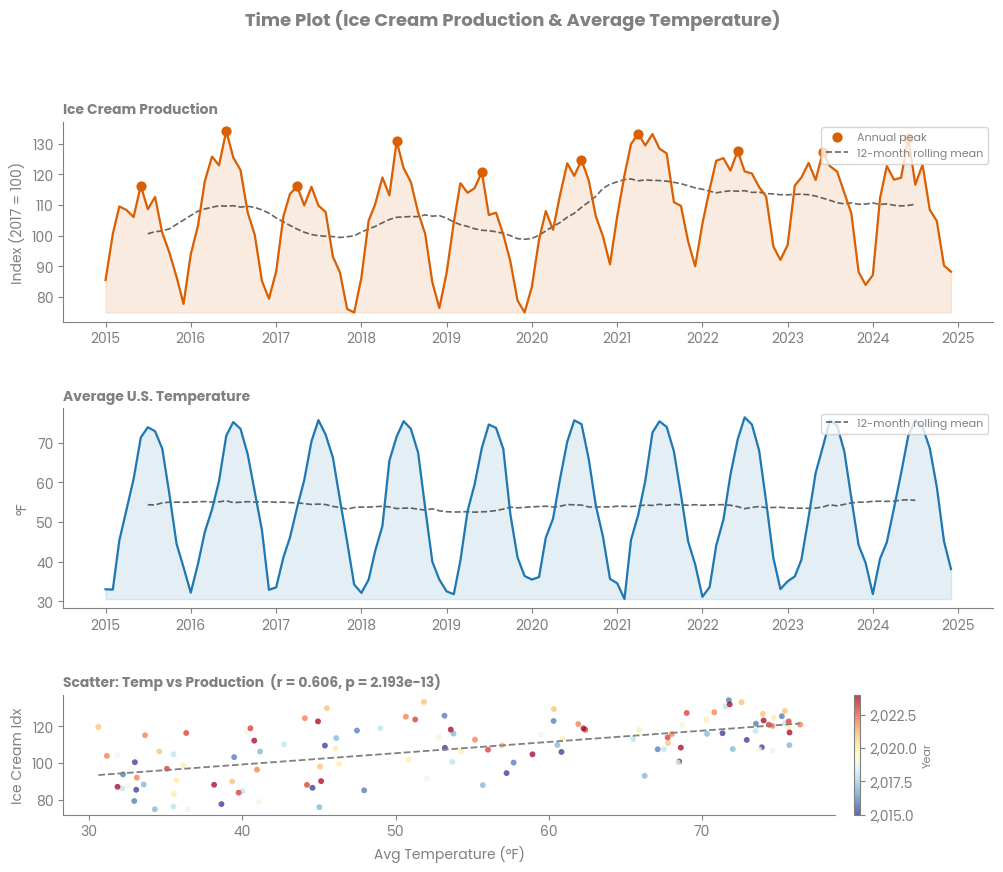


Pearson r (Temp vs Production) = 0.6062,  p-value = 2.1927e-13


In [61]:
fig = plt.figure(figsize=(12, 9))
fig.suptitle("Time Plot (Ice Cream Production & Average Temperature)", fontsize=13, fontweight="bold", y=1.005, color='#808080')

gs = gridspec.GridSpec(3, 1, hspace=0.5, height_ratios=[2, 2, 1.2])

# Ice Cream Production
ax1 = fig.add_subplot(gs[0])
ax1.plot(df.index, df[CREAM], color="#D95F02", lw=1.6, zorder=3)
ax1.fill_between(df.index, df[CREAM].min(), df[CREAM], alpha=0.12, color="#D95F02")

yearly_peak = df[CREAM].groupby(df.index.year).idxmax()
ax1.scatter(yearly_peak, df.loc[yearly_peak, CREAM], color="#D95F02", s=40, zorder=5, label="Annual peak")

rm12 = df[CREAM].rolling(12, center=True).mean()
ax1.plot(df.index, rm12, color="black", lw=1.2, ls="--", alpha=0.6, label="12-month rolling mean")
ax1.set_ylabel("Index (2017 = 100)")
ax1.set_title("Ice Cream Production", loc="left", fontsize=10)
ax1.legend(fontsize=8, loc="upper right")

# Average Temperature
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(df.index, df[TEMP], color="#1F78B4", lw=1.6, zorder=3)
ax2.fill_between(df.index, df[TEMP].min(), df[TEMP], alpha=0.12, color="#1F78B4")
rm12_t = df[TEMP].rolling(12, center=True).mean()
ax2.plot(df.index, rm12_t, color="black", lw=1.2, ls="--", alpha=0.6, label="12-month rolling mean")
ax2.set_ylabel("°F")
ax2.set_title("Average U.S. Temperature", loc="left", fontsize=10)
ax2.legend(fontsize=8, loc="upper right")

# Correlation scatter
ax3 = fig.add_subplot(gs[2])
sc = ax3.scatter(df[TEMP], df[CREAM], c=df.index.year, cmap="RdYlBu_r", s=18, alpha=0.75, edgecolors="none")
m, b, r, p, _ = stats.linregress(df[TEMP], df[CREAM])
x_line = np.linspace(df[TEMP].min(), df[TEMP].max(), 100)
ax3.plot(x_line, m * x_line + b, color="#808080", lw=1.3, ls="--")
ax3.set_xlabel("Avg Temperature (°F)")
ax3.set_ylabel("Ice Cream Idx")
ax3.set_title(f"Scatter: Temp vs Production  (r = {r:.3f}, p = {p:.3e})", loc="left", fontsize=10)
cb = plt.colorbar(sc, ax=ax3, pad=0.02)
cb.set_label("Year", fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nPearson r (Temp vs Production) = {r:.4f},  p-value = {p:.4e}")

In [62]:
# CORRELATION & REGRESSION
m, b, r, p, se = stats.linregress(df[TEMP], df[CREAM])

print("Correlation & Linear Regression (Temp → Production):")
print(f"  {'Pearson r':<30} {r:.4f}")
print(f"  {'R² (variance explained)':<30} {r**2:.4f}  ({r**2*100:.1f}%)")
print(f"  {'p-value':<30} {p:.4e}  ({'significant' if p < 0.05 else 'not significant'} at α=0.05)")
print(f"  {'Slope':<30} {m:.4f}  (per 1°F increase)")
print(f"  {'Intercept':<30} {b:.4f}")
print(f"  {'Std Error':<30} {se:.4f}")

# ANNUAL PEAKS
print("\nAnnual Peak — Ice Cream Production:")
print(f"  {'Year':<8} {'Peak Index':<15} {'Month'}")

yearly_peak = df[CREAM].groupby(df.index.year).idxmax()
for year, idx in yearly_peak.items():
    print(f"  {year:<8} {df.loc[idx, CREAM]:<15.2f} {idx.strftime('%B')}")

# ROLLING MEAN (year-end snapshot)
print("\n12-Month Rolling Mean — Year-End Snapshot:")
print(f"  {'Year':<8} {'Ice Cream (RM12)':<22} {'Temperature (RM12)'}")

rm12_c = df[CREAM].rolling(12, center=True).mean()
rm12_t = df[TEMP].rolling(12, center=True).mean()
year_ends = df.resample("Y").last().index

for idx in year_ends:
    if idx in rm12_c.index and not np.isnan(rm12_c[idx]):
        print(f"  {idx.year:<8} {rm12_c[idx]:<22.2f} {rm12_t[idx]:.2f}")

Correlation & Linear Regression (Temp → Production):
  Pearson r                      0.6062
  R² (variance explained)        0.3675  (36.7%)
  p-value                        2.1927e-13  (significant at α=0.05)
  Slope                          0.6110  (per 1°F increase)
  Intercept                      74.8605
  Std Error                      0.0738

Annual Peak — Ice Cream Production:
  Year     Peak Index      Month
  2015     116.26          June
  2016     134.14          June
  2017     116.04          April
  2018     130.78          June
  2019     120.70          June
  2020     124.62          August
  2021     133.25          April
  2022     127.59          June
  2023     127.24          June
  2024     131.90          June

12-Month Rolling Mean — Year-End Snapshot:
  Year     Ice Cream (RM12)       Temperature (RM12)


Visual inspection of the time series reveals a highly synchronized, cyclical rhythm between average U.S. temperatures and ice cream production. The production index reliably surges alongside warming weather, with annual peaks occurring predominantly in June for 80% of the observed decade. However, the data also captures notable anomalies—specifically early peaks in April (2017, 2021) and a delayed peak in August 2020. These deviations suggest that while seasonal weather is the baseline catalyst, production schedules are likely subjected to external shocks or shifting consumer behaviors during specific years. Furthermore, overlaying a 12-month rolling mean effectively neutralizes the seasonality to reveal the underlying macro trend, illustrating a noticeable contraction in overall production leading into 2020, followed by a gradual but resilient recovery phase.

To rigorously quantify the visual relationship between weather and output, a correlation and linear regression analysis was conducted. The results confirm a statistically significant positive correlation (Pearson r = 0.606, p-value < 0.001). The regression model establishes a baseline slope of 0.611, indicating that every 1°F increase in average U.S. temperature is associated with an approximate 0.61-unit rise in the production index.

However, the most critical insight from this analysis lies in the coefficient of determination (R² = 0.368). This metric reveals that temperature alone explains only about 37% of the variance in ice cream production. From a business intelligence perspective, this is a vital takeaway: while temperature acts as a strong foundational driver for demand, relying solely on weather forecasts for supply chain and production planning is insufficient. The remaining 63% of unexplained variance highlights the presence of other compounding variables—such as targeted marketing campaigns, economic conditions, holiday timing, or localized pricing strategies—that must be accounted for to build a truly robust predictive forecasting model.

## **Seasonal & Subseries Plot**

To isolate the within-year repeating pattern, seasonal plots overlay each year's trajectory across the 12 calendar months. A cross-year monthly mean (dashed black line) is superimposed to anchor the typical seasonal profile. Monthly box plots complement this view by showing the full distribution of each month's values, revealing not only the central tendency but also dispersion and potential outliers per calendar month. Together, these two plots confirm whether a stable, recurring seasonal structure exists in the data.

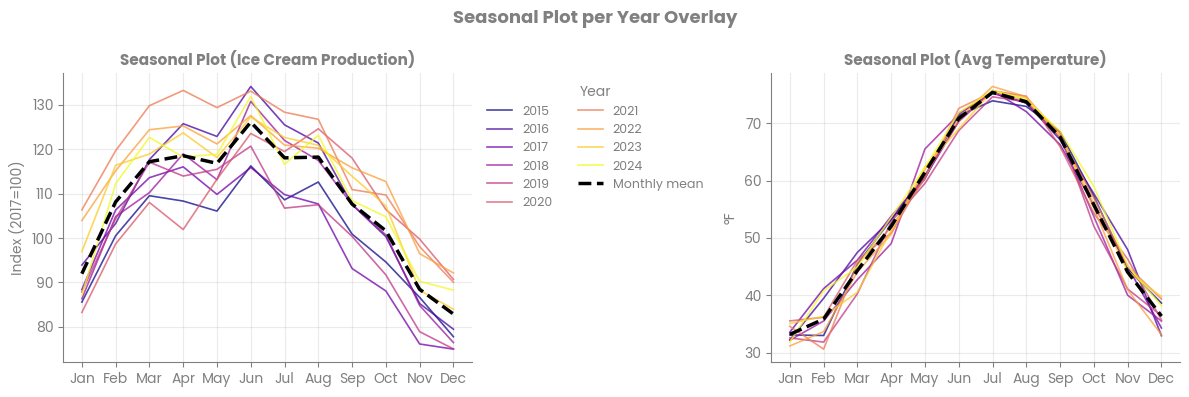

In [63]:
df["_month"] = df.index.month
df["_year"]  = df.index.year

month_labels = ["Jan","Feb","Mar","Apr","May","Jun", "Jul","Aug","Sep","Oct","Nov","Dec"]
cmap_yr = plt.cm.get_cmap("plasma", df["_year"].nunique())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Seasonal Plot per Year Overlay", fontsize=13, fontweight="bold", color='#808080')

for i, (year, grp) in enumerate(df.groupby("_year")):
    grp_s = grp.sort_values("_month")
    axes[0].plot(grp_s["_month"], grp_s[CREAM], color=cmap_yr(i), lw=1.2, alpha=0.75, label=str(year))
    axes[1].plot(grp_s["_month"], grp_s[TEMP], color=cmap_yr(i), lw=1.2, alpha=0.75)

# Monthly mean overlay
for ax, col in zip(axes, [CREAM, TEMP]):
    monthly_mean = df.groupby("_month")[col].mean()
    ax.plot(monthly_mean.index, monthly_mean.values, color="black", lw=2.5, ls="--", zorder=5, label="Monthly mean")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.grid(alpha=0.25)

axes[0].set_title(f"Seasonal Plot ({CREAM})", fontsize=11)
axes[0].set_ylabel("Index (2017=100)")

leg = axes[0].legend(title="Year", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, ncol=2, frameon=False)
leg.get_title().set_color("#808080")

axes[1].set_title(f"Seasonal Plot ({TEMP})", fontsize=11)
axes[1].set_ylabel("°F")

plt.tight_layout()
plt.show()

Deepening the seasonal exploration via per-year overlays reveals a subtle but highly critical operational insight: a distinct phase lag between peak environmental temperature and peak manufacturing output. While average U.S. temperatures predictably culminate in July (75.4°F), ice cream production consistently peaks a month earlier in June, reaching a multi-year average index of 126.1. Conversely, the production trough occurs in December (82.9), leading the true temperature trough in January (33.2°F) by exactly one month.

This systemic front-running (quantified by a 1.52x peak-to-trough production multiplier) strongly reflects forward-looking logistics. Manufacturers aggressively ramp up capacity in late spring to build inventory insulation before peak consumer demand hits in mid-summer, and scale down operations before winter fully sets in. This demonstrates that supply chain scheduling is dictated by market anticipation and inventory management rather than pure, real-time reactive adjustments to the weather.

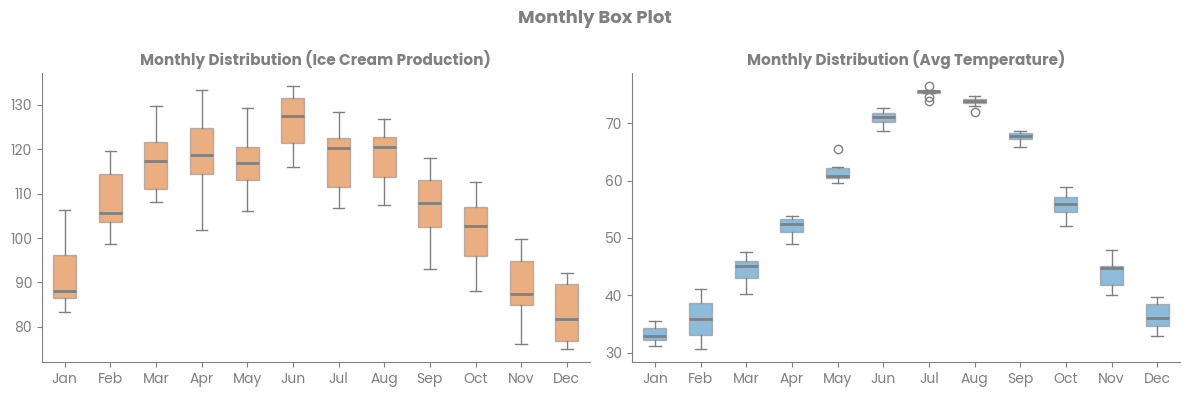

In [64]:
# Monthly Box Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Monthly Box Plot", fontsize=13, fontweight="bold", color='#808080')

for ax, col, color in zip(axes, [CREAM, TEMP], ["#D95F02", "#1F78B4"]):
    data_by_month = [df.loc[df["_month"] == m, col].values for m in range(1, 13)]
    bp = ax.boxplot(data_by_month, patch_artist=True, medianprops=dict(color="#808080", lw=2))
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_title(f"Monthly Distribution ({col})", fontsize=11)

plt.tight_layout()
plt.show()

df.drop(columns=["_month", "_year"], inplace=True)

In [65]:
df["_month"] = df.index.month
df["_year"]  = df.index.year
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# Monthly Mean
monthly_mean_c = df.groupby("_month")[CREAM].mean()
monthly_mean_t = df.groupby("_month")[TEMP].mean()

print("Monthly Mean (across all years):")
print(f"  {'Month':<8} {'Ice Cream Index':<22} {'Avg Temperature (°F)'}")
for m in range(1, 13):
    print(f"  {month_labels[m-1]:<8} {monthly_mean_c[m]:<22.2f} {monthly_mean_t[m]:.2f}")

peak_c = monthly_mean_c.idxmax()
peak_t = monthly_mean_t.idxmax()
low_c  = monthly_mean_c.idxmin()
low_t  = monthly_mean_t.idxmin()
print(f"\n  ↑ Ice Cream peak   : {month_labels[peak_c-1]} ({monthly_mean_c[peak_c]:.2f})")
print(f"  ↓ Ice Cream trough : {month_labels[low_c-1]}  ({monthly_mean_c[low_c]:.2f})")
print(f"  ↑ Temp peak        : {month_labels[peak_t-1]} ({monthly_mean_t[peak_t]:.2f} °F)")
print(f"  ↓ Temp trough      : {month_labels[low_t-1]}  ({monthly_mean_t[low_t]:.2f} °F)")

# Year-over-Year per Month
print("\nIce Cream Index Per Month, Per Year (Seasonal Grid):")
pivot_c = df.pivot_table(index="_year", columns="_month", values=CREAM)
pivot_c.columns = month_labels
print(pivot_c.round(1).to_string())

print("\nAvg Temperature (°F) Per Month, Per Year (Seasonal Grid):")
pivot_t = df.pivot_table(index="_year", columns="_month", values=TEMP)
pivot_t.columns = month_labels
print(pivot_t.round(1).to_string())

# Monthly Distribution
print("\nMonthly Distribution Summary — Ice Cream Index:")
print(f"  {'Month':<8} {'Min':>7} {'Q1':>7} {'Median':>9} {'Q3':>7} {'Max':>7} {'Std':>7}")
for m in range(1, 13):
    vals = df.loc[df["_month"] == m, CREAM]
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    print(f"  {month_labels[m-1]:<8} {vals.min():>7.1f} {q1:>7.1f} {med:>9.1f} {q3:>7.1f} {vals.max():>7.1f} {vals.std():>7.2f}")

print("\nMonthly Distribution Summary — Avg Temperature (°F):")
print(f"  {'Month':<8} {'Min':>7} {'Q1':>7} {'Median':>9} {'Q3':>7} {'Max':>7} {'Std':>7}")
for m in range(1, 13):
    vals = df.loc[df["_month"] == m, TEMP]
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    print(f"  {month_labels[m-1]:<8} {vals.min():>7.1f} {q1:>7.1f} {med:>9.1f} {q3:>7.1f} {vals.max():>7.1f} {vals.std():>7.2f}")

# Seasonality Strength
print("\nSeasonality Strength (CoV monthly means):")
for label, mm in [("Ice Cream", monthly_mean_c), ("Temperature", monthly_mean_t)]:
    cov = mm.std() / mm.mean() * 100
    peak_to_trough = mm.max() / mm.min()
    print(f"  {label:<15} CoV = {cov:.1f}%   Peak-to-trough ratio = {peak_to_trough:.2f}x")

print("\n")
df.drop(columns=["_month", "_year"], inplace=True)

Monthly Mean (across all years):
  Month    Ice Cream Index        Avg Temperature (°F)
  Jan      91.98                  33.18
  Feb      108.15                 35.85
  Mar      117.20                 44.32
  Apr      118.54                 52.03
  May      116.83                 61.44
  Jun      126.12                 70.80
  Jul      118.07                 75.36
  Aug      118.23                 73.72
  Sep      107.67                 67.58
  Oct      101.64                 55.77
  Nov      88.47                  44.04
  Dec      82.89                  36.39

  ↑ Ice Cream peak   : Jun (126.12)
  ↓ Ice Cream trough : Dec  (82.89)
  ↑ Temp peak        : Jul (75.36 °F)
  ↓ Temp trough      : Jan  (33.18 °F)

Ice Cream Index Per Month, Per Year (Seasonal Grid):
          Jan     Feb     Mar     Apr     May     Jun     Jul     Aug     Sep     Oct    Nov    Dec
_year                                                                                              
2015   85.600 100.500 109.50

Analyzing the monthly distributions through box plots highlights a striking contrast in predictability between the two variables. The climate data acts as an exceptionally rigid, deterministic baseline; its year-over-year variation across the decade is remarkably narrow, particularly in July where the standard deviation drops to a mere 0.69°F. In stark contrast, ice cream production exhibits substantial vertical dispersion within identical calendar months across different years.

April demonstrates the highest operational volatility (Std: 9.11), where production index values range from a low of 101.9 in 2020 to a peak of 133.3 in 2021. This variance asymmetry indicates that while temperature provides a stable seasonal framework, the actual scale of manufacturing output possesses significant elasticity. The noticeable widening of the distribution boxes during shoulder seasons (spring and autumn) suggests that non-weather factors (such as shifting holiday calendars, corporate procurement cycles, or macroeconomic disruptions) exert their strongest influence during these transition periods. For predictive modeling, this dictates that feature engineering must focus heavily on capture-elasticity parameters during transition months to reduce forecast errors.

## **Seasonal Decomposition**

STL (Seasonal-Trend decomposition using LOESS) is applied to formally separate each series into three additive components: trend, seasonality, and residual. The robust=True option reduces the influence of outliers during the LOESS smoothing step, making the decomposition more reliable in the presence of anomalous observations. The ratio of seasonal variance to total variance is computed as a quantitative measure of how much of the overall variability is attributable to the seasonal cycle, an important input when deciding whether seasonal differencing or seasonal model terms are warranted.

Ice Cream Production: Seasonal variance / Total variance = 76.6%
Avg Temperature: Seasonal variance / Total variance = 94.2%


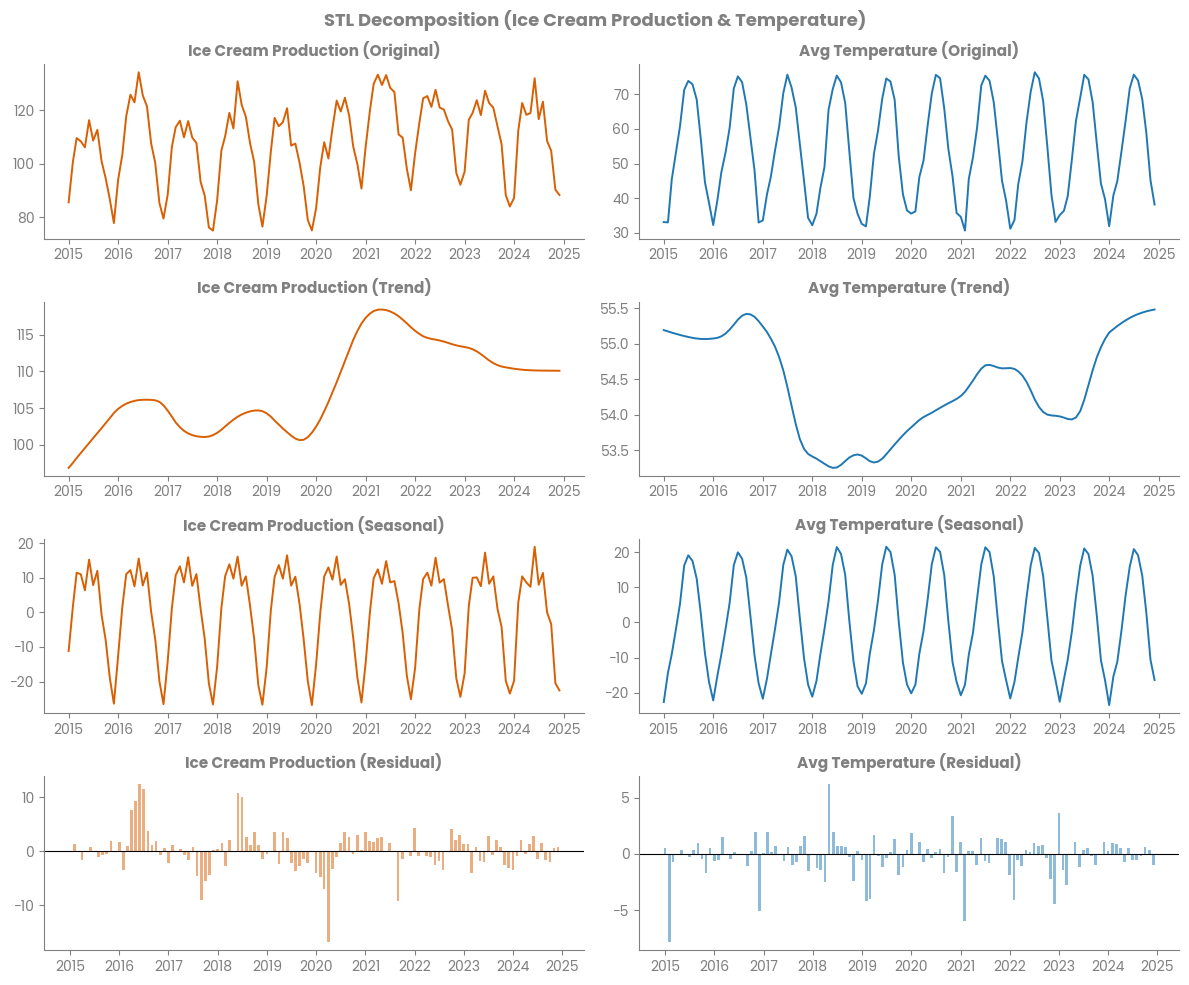

In [66]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10))
fig.suptitle("STL Decomposition (Ice Cream Production & Temperature)", fontsize=13, fontweight="bold", color='#808080')

for col_idx, (col, color) in enumerate([(CREAM, "#D95F02"), (TEMP, "#1F78B4")]):
    stl = STL(df[col], period=12, robust=True).fit()
    components = {
        "Original"  : df[col],
        "Trend"     : stl.trend,
        "Seasonal"  : stl.seasonal,
        "Residual"  : stl.resid,
    }
    for row_idx, (label, series) in enumerate(components.items()):
        ax = axes[row_idx, col_idx]
        if label == "Residual":
            ax.bar(series.index, series.values, color=color, alpha=0.5, width=20)
            ax.axhline(0, color="black", lw=0.8)
        else:
            ax.plot(series.index, series.values, color=color, lw=1.4)
        ax.set_title(f"{col} ({label})", fontsize=11)

    # Variance explained by seasonal component
    var_seasonal = np.var(stl.seasonal)
    var_total    = np.var(df[col])
    print(f"{col}: Seasonal variance / Total variance = " f"{var_seasonal/var_total*100:.1f}%")

plt.tight_layout()
plt.show()

In [67]:
for col in [CREAM, TEMP]:
    stl = STL(df[col], period=12, robust=True).fit()

    # Variance Decomposition
    var_total    = np.var(df[col])
    var_trend    = np.var(stl.trend)
    var_seasonal = np.var(stl.seasonal)
    var_resid    = np.var(stl.resid)

    print(f"  {col}")
    print(f"\n  Variance Decomposition:")
    print(f"    {'Component':<20} {'Variance':>12} {'% of Total':>12}")
    print(f"    {'Trend':<20} {var_trend:>12.4f} {var_trend/var_total*100:>11.1f}%")
    print(f"    {'Seasonal':<20} {var_seasonal:>12.4f} {var_seasonal/var_total*100:>11.1f}%")
    print(f"    {'Residual':<20} {var_resid:>12.4f} {var_resid/var_total*100:>11.1f}%")
    print(f"    {'Total (Original)':<20} {var_total:>12.4f} {'100.0':>11}%")

    # Trend Summary
    trend_start = stl.trend.iloc[6]
    trend_end   = stl.trend.iloc[-6]
    trend_delta = trend_end - trend_start

    print(f"\n  Trend Component:")
    print(f"    Start (approx) : {trend_start:.2f}")
    print(f"    End   (approx) : {trend_end:.2f}")
    print(f"    Net change     : {trend_delta:+.2f}  "
          f"({'↑ upward' if trend_delta > 0 else '↓ downward'})")
    print(f"    Min            : {stl.trend.min():.2f}  "
          f"({stl.trend.idxmin().strftime('%Y-%m')})")
    print(f"    Max            : {stl.trend.max():.2f}  "
          f"({stl.trend.idxmax().strftime('%Y-%m')})")

    # SEASONAL PATTERN
    month_labels = ["Jan","Feb","Mar","Apr","May","Jun", "Jul","Aug","Sep","Oct","Nov","Dec"]
    seasonal_df  = stl.seasonal.copy().to_frame(name="seasonal")
    seasonal_df["month"] = seasonal_df.index.month
    avg_seasonal = seasonal_df.groupby("month")["seasonal"].mean()

    peak_m  = avg_seasonal.idxmax()
    trough_m = avg_seasonal.idxmin()
    amplitude = avg_seasonal.max() - avg_seasonal.min()

    print(f"\n  Seasonal Component (avg per month):")
    print(f"    {'Month':<8} {'Avg Seasonal Effect':>22}")
    for m in range(1, 13):
        marker = " (peak)" if m == peak_m else (" (trough)" if m == trough_m else "")
        print(f"    {month_labels[m-1]:<8} {avg_seasonal[m]:>+22.3f}{marker}")
    print(f"\n    Amplitude (peak−trough) : {amplitude:.3f}")

    # Residual Diagnostics
    resid = stl.resid
    outlier_thresh = 2 * resid.std()
    outliers = resid[resid.abs() > outlier_thresh]

    print(f"\n  Residual Diagnostics:")
    print(f"    Mean   : {resid.mean():.4f}  (ideal ≈ 0)")
    print(f"    Std    : {resid.std():.4f}")
    print(f"    Min    : {resid.min():.4f}  ({resid.idxmin().strftime('%Y-%m')})")
    print(f"    Max    : {resid.max():.4f}  ({resid.idxmax().strftime('%Y-%m')})")
    print(f"    Outliers (|resid| > 2σ) : {len(outliers)}")
    if len(outliers) > 0:
        for dt, val in outliers.sort_values(key=abs, ascending=False).head(5).items():
            print(f"      {dt.strftime('%Y-%m')}  {val:+.3f}")

  Ice Cream Production

  Variance Decomposition:
    Component                Variance   % of Total
    Trend                     33.5677        14.8%
    Seasonal                 173.9228        76.6%
    Residual                  14.0246         6.2%
    Total (Original)         227.1293       100.0%

  Trend Component:
    Start (approx) : 100.93
    End   (approx) : 110.13
    Net change     : +9.20  (↑ upward)
    Min            : 96.88  (2015-01)
    Max            : 118.44  (2021-05)

  Seasonal Component (avg per month):
    Month       Avg Seasonal Effect
    Jan                     -15.287
    Feb                      +1.111
    Mar                     +10.396
    Apr                     +11.941
    May                      +8.217
    Jun                     +16.198 (peak)
    Jul                      +7.992
    Aug                     +10.507
    Sep                      +1.245
    Oct                      -6.452
    Nov                     -19.702
    Dec                  

A comprehensive synthesis of the decade-long dataset reveals that while weather acts as the fundamental pacemaker for the ice cream industry, it is entirely insufficient as a standalone predictor for manufacturing output. The initial bivariate analysis establishes a statistically significant correlation between average temperature and production (r = 0.606), yet the coefficient of determination (R² = 36.7%) clearly dictates that nearly two-thirds of all production variance remains unexplained by climate alone.

This critical limitation is fully illuminated through the STL decomposition. The analysis juxtaposes a highly deterministic climate baseline—where seasonality dictates over 94% of temperature variance—against a much more volatile, dynamic manufacturing structure. Ice cream production is heavily influenced by significant multi-year macro trends, which independently drive nearly 15% of its variance. Furthermore, the presence of extreme residual anomalies, most notably the unprecedented April 2020 operational contraction, highlights the supply chain's vulnerability to exogenous macroeconomic shocks that ignore seasonal expectations.

These insights establish a clear roadmap for developing a robust predictive architecture. Deploying a simple univariate forecasting algorithm on this dataset would yield fundamentally flawed, reactive business intelligence. Because production reliably front-runs temperature by a full month (peaking in June versus July), any predictive model must engineered with lagged climate features to accurately reflect forward-looking inventory logistics.

More importantly, the prominence of structural trend shifts and high-magnitude stochastic anomalies dictates the necessity of a multivariate forecasting approach. Advanced architectures, such as SARIMAX or Prophet, should be prioritized. These models must incorporate external regressors (including explicit event flags for pandemic lockdowns, shifting holiday timelines, and targeted marketing cycles) to successfully capture the operational elasticity during transition months and deliver enterprise-grade, resilient forecasts.

## **Stationarity Tests**

Many classical time series models (e.g., ARIMA) require stationarity, a condition where the mean and variance of the series do not change over time. Two complementary hypothesis tests are used here: the Augmented Dickey-Fuller (ADF) test, which has a null hypothesis of a unit root (non-stationary), and the KPSS test, which has a null hypothesis of stationarity. Using both tests together mitigates the risk of drawing incorrect conclusions from a single test. The analysis is repeated on the first-differenced and seasonally-differenced series to determine the minimum degree of differencing required to achieve stationarity.

In [68]:
def stationarity_summary(series, name):
    """ADF (H0: unit root) + KPSS (H0: stationary)."""
    adf_stat, adf_p, _, _, adf_cv, _ = adfuller(series.dropna(), autolag="AIC")
    kpss_stat, kpss_p, _, kpss_cv    = kpss(series.dropna(), regression="c", nlags="auto")

    print(f"\n  {name}:")
    print(f"  ADF  : stat={adf_stat:8.4f}  p={adf_p:.4f}  "
          f"{'Stationary' if adf_p < 0.05 else '✗ Unit root likely'}")
    print(f"  KPSS : stat={kpss_stat:8.4f}  p={kpss_p:.4f}  "
          f"{'Stationary' if kpss_p > 0.05 else '✗ Non-stationary'}")
    return adf_p, kpss_p

print("Level (original series)")
adf_cream, kpss_cream = stationarity_summary(df[CREAM], CREAM)
adf_temp,  kpss_temp  = stationarity_summary(df[TEMP],  TEMP)

# First differencing jika non-stationary
print("\nFirst Difference")
stationarity_summary(df[CREAM].diff(), f"Δ{CREAM}")
stationarity_summary(df[TEMP].diff(),  f"Δ{TEMP}")

print("\nSeasonal Difference (lag-12)")
stationarity_summary(df[CREAM].diff(12), f"Δ₁₂{CREAM}")
stationarity_summary(df[TEMP].diff(12),  f"Δ₁₂{TEMP}")

Level (original series)

  Ice Cream Production:
  ADF  : stat= -2.5770  p=0.0978  ✗ Unit root likely
  KPSS : stat=  0.2743  p=0.1000  Stationary

  Avg Temperature:
  ADF  : stat= -1.2240  p=0.6632  ✗ Unit root likely
  KPSS : stat=  0.0184  p=0.1000  Stationary

First Difference

  ΔIce Cream Production:
  ADF  : stat= -2.6471  p=0.0836  ✗ Unit root likely
  KPSS : stat=  0.0420  p=0.1000  Stationary

  ΔAvg Temperature:
  ADF  : stat=-10.9978  p=0.0000  Stationary
  KPSS : stat=  0.0321  p=0.1000  Stationary

Seasonal Difference (lag-12)

  Δ₁₂Ice Cream Production:
  ADF  : stat= -2.5047  p=0.1143  ✗ Unit root likely
  KPSS : stat=  0.0944  p=0.1000  Stationary

  Δ₁₂Avg Temperature:
  ADF  : stat= -9.7994  p=0.0000  Stationary
  KPSS : stat=  0.2488  p=0.1000  Stationary


(np.float64(6.050705961765414e-17), np.float64(0.1))

Before constructing any autoregressive forecasting architecture, validating the stationarity of the time series is an essential econometric prerequisite. Running the Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin (KPSS) tests on the raw levels reveals a classic, highly nuanced contradiction. For both Ice Cream Production and Average Temperature, the ADF test fails to reject the null hypothesis of a unit root ($p = 0.098$ and $p = 0.663$, respectively), suggesting non-stationarity. Conversely, the KPSS test fails to reject its null hypothesis of stationarity ($p = 0.100$ for both).

This divergence is a frequent phenomenon in data characterized by aggressive, deterministic seasonality. Because the ADF test relies on an autoregressive framework, the stark, repeating seasonal peaks and troughs confound the model into misidentifying these bounded oscillations as a stochastic random walk. Meanwhile, the KPSS test evaluates stationarity around a deterministic mean or trend, correctly recognizing that the fluctuations are tightly bounded within stable historical limits. This diagnostic tension signals that standard first-differencing alone may not be the optimal path to stationarity, as the underlying "non-stationarity" flagged by the ADF test is driven by cyclicality rather than a true stochastic trend.

To isolate the structural root of this variance, both first-differencing (lag-1) and seasonal differencing (lag-12) transformations were applied. For the Average Temperature series, both transformations decisively resolve the unit root issue, with the first-difference ADF statistic plunging to a highly significant level ($p < 0.001$). This confirms that the climate data can be converted into a completely stationary series through basic differencing, removing the predictable annual weather pattern to leave a mean-reverting residual.

However, the Ice Cream Production series exhibits remarkable resilience to standard transformations. Even after applying a first difference ($p = 0.084$) or a seasonal difference ($p = 0.114$), the ADF test stubbornly maintains that a unit root is likely present, while the KPSS test continuously flags the series as stationary. This persistent contradiction provides critical architectural guidance for the upcoming modeling phase. It indicates that the production series contains a mixture of deterministic seasonality and a non-stationary macro trend—the exact post-2020 structural expansion observed during the STL decomposition phase.

For model identification, this dictates that a standard ARIMA approach will fail to capture the true data-generating process. Instead, the forecasting architecture must leverage a seasonal framework (such as SARIMA) where the seasonal differencing parameter ($D=1$) is explicitly defined to neutralize the cyclical bounds, paired with a deterministic trend component or an external macro regressor to handle the shifting multi-year baseline trend without over-differencing the stable seasonal signals.

## **Rolling Statistics**

Rolling mean and rolling standard deviation (computed over a 12-month window) serve as a practical check for non-stationarity: a series with a drifting rolling mean exhibits a time-varying level, while a drifting rolling standard deviation suggests heteroscedasticity. These plots complement the formal ADF/KPSS tests by providing an intuitive visual confirmation, particularly useful when communicating findings to non-technical audiences. The 12-month window is chosen to align with the dominant seasonal cycle, ensuring that the rolling statistics reflect genuine trend changes rather than seasonal fluctuations.

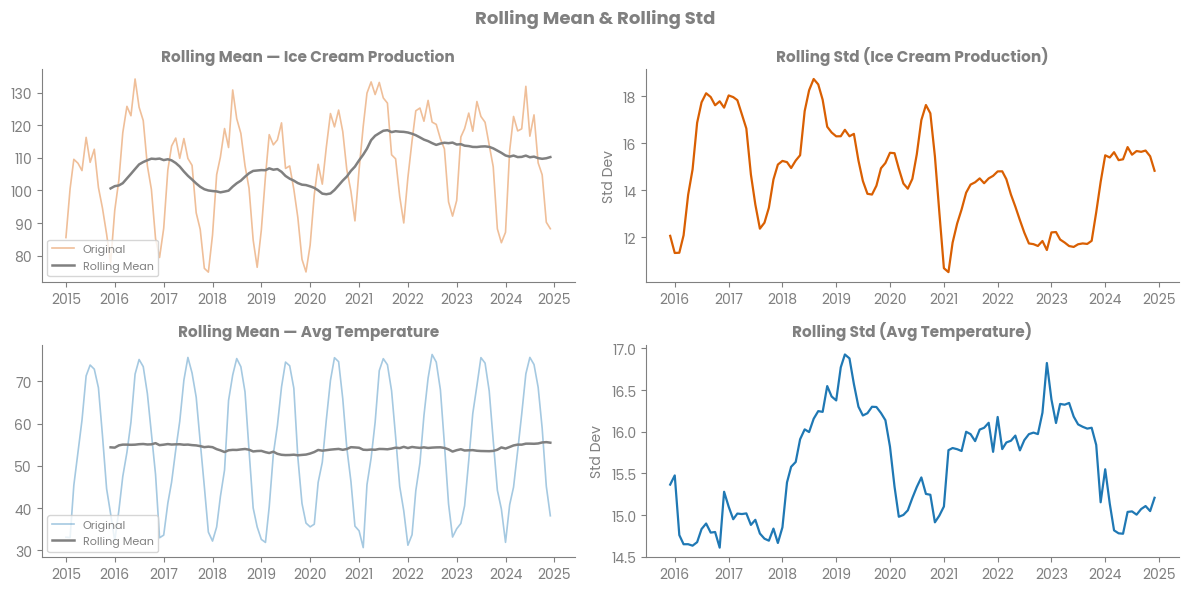

In [69]:
window = 12

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle("Rolling Mean & Rolling Std", fontsize=13, fontweight="bold", color='#808080')

for row, (col, color) in enumerate([(CREAM, "#D95F02"), (TEMP, "#1F78B4")]):
    roll_mean = df[col].rolling(window).mean()
    roll_std  = df[col].rolling(window).std()

    # Rolling mean
    axes[row, 0].plot(df.index, df[col], color=color, alpha=0.4, lw=1.2, label="Original")
    axes[row, 0].plot(df.index, roll_mean, color="#808080", lw=1.8, label="Rolling Mean")
    axes[row, 0].set_title(f"Rolling Mean — {col}", fontsize=11)
    axes[row, 0].legend(fontsize=8)

    # Rolling std
    axes[row, 1].plot(df.index, roll_std, color=color, lw=1.6)
    axes[row, 1].set_title(f"Rolling Std ({col})", fontsize=11)
    axes[row, 1].set_ylabel("Std Dev")

plt.tight_layout()
plt.show()

In [70]:
window = 12

for col in [CREAM, TEMP]:
    roll_mean = df[col].rolling(window).mean()
    roll_std  = df[col].rolling(window).std()

    # YEAR-END SNAPSHOT
    snap = df[col].resample("Y").last().index

    print(f"  {col}")
    print(f"\n  Year-End Snapshot (rolling {window}-month):")
    print(f"    {'Year':<8} {'Original':>10} {'Roll Mean':>12} {'Roll Std':>10} {'Δ Mean YoY':>12}")
    print(f"    {'─'*55}")

    prev_mean = None
    for idx in snap:
        if idx not in roll_mean.index or np.isnan(roll_mean[idx]):
            continue
        orig  = df.loc[idx, col]
        rmean = roll_mean[idx]
        rstd  = roll_std[idx]
        delta = f"{rmean - prev_mean:+.2f}" if prev_mean is not None else "—"
        print(f"    {idx.year:<8} {orig:>10.2f} {rmean:>12.2f} {rstd:>10.2f} {delta:>12}")
        prev_mean = rmean

    # ROLLING MEAN SUMMARY ───────────────────────────────────
    print(f"\n  Rolling Mean — Overall:")
    print(f"    Min  : {roll_mean.min():.2f}  ({roll_mean.idxmin().strftime('%Y-%m')})")
    print(f"    Max  : {roll_mean.max():.2f}  ({roll_mean.idxmax().strftime('%Y-%m')})")
    print(f"    Range: {roll_mean.max() - roll_mean.min():.2f}")

    first_valid = roll_mean.dropna().iloc[0]
    last_valid  = roll_mean.dropna().iloc[-1]
    net_drift   = last_valid - first_valid
    print(f"    Net drift (first→last valid): {net_drift:+.2f}  "
          f"({'↑' if net_drift > 0 else '↓'})")

    # ROLLING STD SUMMARY (volatility) ──────────────────────
    print(f"\n  Rolling Std — Volatility:")
    print(f"    Mean Std : {roll_std.mean():.2f}  (avg volatility)")
    print(f"    Min  Std : {roll_std.min():.2f}  ({roll_std.idxmin().strftime('%Y-%m')})  ← most stable")
    print(f"    Max  Std : {roll_std.max():.2f}  ({roll_std.idxmax().strftime('%Y-%m')})  ← most volatile")

    # Periode volatilitas tinggi (> mean + 1 std)
    high_vol_thresh = roll_std.mean() + roll_std.std()
    high_vol = roll_std[roll_std > high_vol_thresh]
    print(f"\n   High-Volatility Periods (roll_std > {high_vol_thresh:.2f}):")
    if len(high_vol) == 0:
        print("    — None detected —")
    else:
        # Kelompokkan periode bersebelahan
        groups, group = [], []
        for dt in high_vol.index:
            if not group or (dt - group[-1]).days <= 40:
                group.append(dt)
            else:
                groups.append(group)
                group = [dt]
        if group:
            groups.append(group)
        for g in groups:
            print(f"    {g[0].strftime('%Y-%m')} → {g[-1].strftime('%Y-%m')}  "
                  f"({len(g)} months,  peak std = {roll_std[g].max():.2f})")

  Ice Cream Production

  Year-End Snapshot (rolling 12-month):
    Year       Original    Roll Mean   Roll Std   Δ Mean YoY
    ───────────────────────────────────────────────────────

  Rolling Mean — Overall:
    Min  : 98.85  (2020-05)
    Max  : 118.46  (2021-08)
    Range: 19.62
    Net drift (first→last valid): +9.60  (↑)

  Rolling Std — Volatility:
    Mean Std : 14.64  (avg volatility)
    Min  Std : 10.52  (2021-02)  ← most stable
    Max  Std : 18.73  (2018-08)  ← most volatile

   High-Volatility Periods (roll_std > 16.72):
    2016-06 → 2017-04  (11 months,  peak std = 18.12)
    2018-06 → 2018-10  (5 months,  peak std = 18.73)
    2020-08 → 2020-10  (3 months,  peak std = 17.62)
  Avg Temperature

  Year-End Snapshot (rolling 12-month):
    Year       Original    Roll Mean   Roll Std   Δ Mean YoY
    ───────────────────────────────────────────────────────

  Rolling Mean — Overall:
    Min  : 52.50  (2019-10)
    Max  : 55.62  (2024-11)
    Range: 3.12
    Net drift (fir

To evaluate the stationarity of the dataset, a 12-month rolling window was applied to extract the underlying mean and standard deviation. This approach effectively smooths out the strong annual seasonality visible in the original observations, allowing us to isolate and assess long-term trends and structural shifts in volatility.

The Ice Cream Production series demonstrates clear non-stationary characteristics, primarily driven by a shifting trend. The rolling mean exhibits a notable positive drift of +9.60 over the observed timeline, fluctuating significantly from a low of 98.85 in May 2020 to a peak of 118.46 in August 2021. Furthermore, the variance is not constant. While the baseline volatility averages a standard deviation of 14.64, the series experienced distinct high-volatility regimes. Extended periods of instability occurred from mid-2016 through early 2017, and again in late 2018, where the standard deviation reached its absolute maximum of 18.73. Conversely, the production volume stabilized most prominently around February 2021, where the rolling standard deviation dropped to an observed minimum of 10.52.

Conversely, the Average Temperature series exhibits a highly stable rolling mean. The central tendency fluctuates within a very tight band of just 3.12 units across the entire dataset, recording a negligible net drift of +1.10. However, while the mean remains relatively stationary, the variance exhibits shifting behavior over time. The temperature's rolling standard deviation averages 15.59, with periods of elevated climatic volatility observed primarily between late 2018 and mid-2019—peaking at 16.93 in March 2019—along with subsequent minor spikes in late 2022 and early 2023. The most stable temperature patterns were recorded earlier in the timeline, bottoming out at a standard deviation of 14.61 in late 2016.

Overall, the shifting upward trend in ice cream production and the time-varying volatility present in both series indicate the presence of non-stationarity. These diagnostics suggest that subsequent modeling steps will require appropriate transformations, such as differencing or seasonal decomposition, to stabilize the mean and variance before applying predictive time series algorithms.

## **Lag Plot**

Lag plots are scatter plots of a series against a lagged version of itself, used to visually assess the nature and strength of autocorrelation at specific lags. A strong linear pattern indicates significant positive autocorrelation at that lag, while a random cloud suggests no autocorrelation. The selection of lags (1, 2, 3, 6, 9, 12, 24, and 36 months) is deliberate short lags capture local persistence, lag 12 targets annual seasonality, and lags 24 and 36 probe multi-year cycles. Pearson's r is annotated on each panel to quantify the relationship.

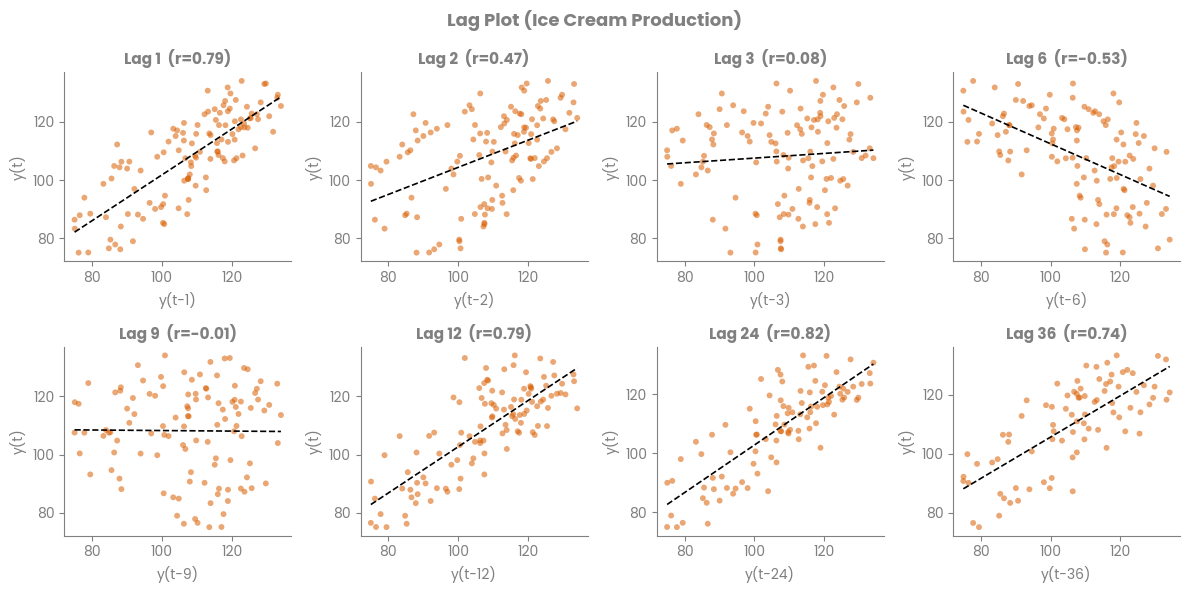

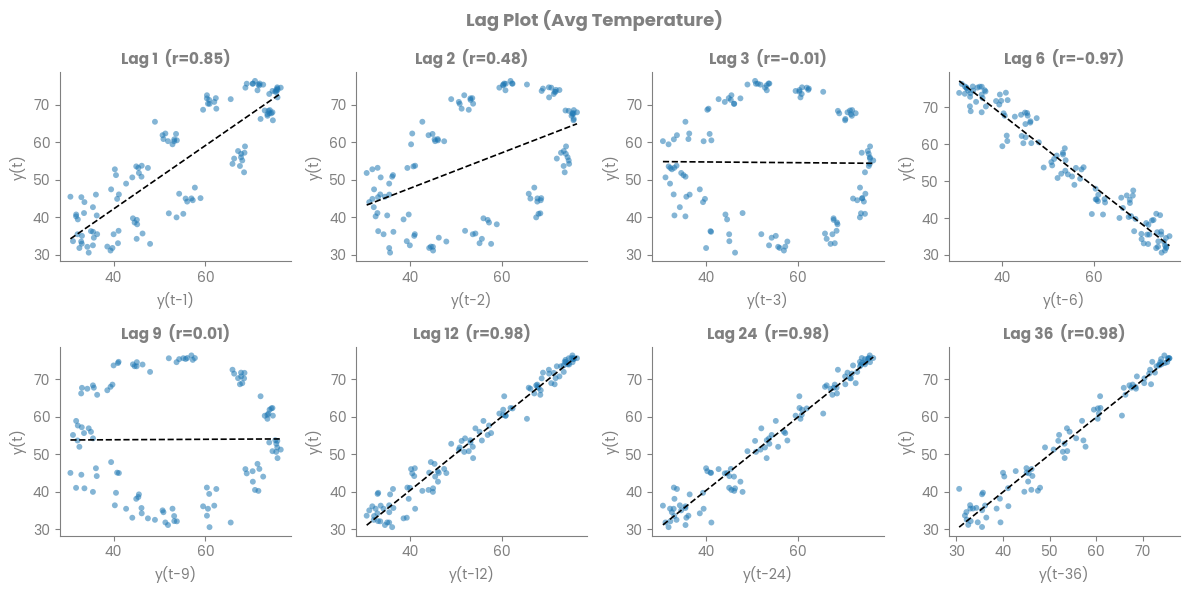

In [71]:
lags_to_show = [1, 2, 3, 6, 9, 12, 24, 36]

for col, color, short in [(CREAM, "#D95F02", "cream"), (TEMP, "#1F78B4", "temp")]:
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle(f"Lag Plot ({col})", fontsize=13, fontweight="bold", color='#808080')

    for ax, lag in zip(axes.flatten(), lags_to_show):
        lag_plot(df[col], lag=lag, ax=ax, c=color, alpha=0.55, edgecolors="none", s=18)
        valid = df[[col]].assign(lagged=df[col].shift(lag)).dropna()
        m_, b_, r_, _, _ = stats.linregress(valid["lagged"], valid[col])
        x_ = np.linspace(valid["lagged"].min(), valid["lagged"].max(), 50)
        ax.plot(x_, m_ * x_ + b_, color="black", lw=1.2, ls="--")
        ax.set_title(f"Lag {lag}  (r={r_:.2f})", fontsize=11)
        ax.set_xlabel(f"y(t-{lag})", fontsize=10)
        ax.set_ylabel("y(t)", fontsize=10)

    plt.tight_layout()
    plt.show()

In [72]:
lags_to_show = [1, 2, 3, 6, 9, 12, 24, 36]

print("LAG PLOT ANALYSIS (Autocorrelation per Lag)")

for col in [CREAM, TEMP]:
    print(f"\n{col}")

    # Lag Correlation Table
    print(f"\n  Pearson r per Lag:")
    print(f"    {'Lag':<8} {'r':>8} {'R²':>8} {'p-value':>14} {'Slope':>9} {'Interpretation'}")

    results = {}
    for lag in lags_to_show:
        valid = df[[col]].assign(lagged=df[col].shift(lag)).dropna()
        m, b, r, p, se = stats.linregress(valid["lagged"], valid[col])

        if abs(r) >= 0.7:
            interp = "strong"
        elif abs(r) >= 0.4:
            interp = "moderate"
        elif abs(r) >= 0.2:
            interp = "weak"
        else:
            interp = "negligible"

        print(f"    {lag:<8} {r:>8.3f} {r**2:>8.3f} {p:>14.3e} {m:>9.3f}  {interp}")
        results[lag] = {"r": r, "r2": r**2, "p": p, "slope": m}

    # Highlight
    best_lag  = max(results, key=lambda k: abs(results[k]["r"]))
    worst_lag = min(results, key=lambda k: abs(results[k]["r"]))

    print(f"\n  Highlights:")
    print(f"   - Strongest autocorrelation : Lag {best_lag:>2}  "
          f"(r = {results[best_lag]['r']:+.3f})")
    print(f"   - Weakest  autocorrelation  : Lag {worst_lag:>2}  "
          f"(r = {results[worst_lag]['r']:+.3f})")

    # Cek seasonality signature (lag 12 & 24)
    r12 = results.get(12, {}).get("r", None)
    r24 = results.get(24, {}).get("r", None)
    if r12 and r24:
        print(f"\n  Seasonality Check (lag 12 & 24):")
        print(f"    Lag 12 r = {r12:+.3f}   Lag 24 r = {r24:+.3f}")
        if r12 > 0.5 and r24 > 0.3:
            print(f"    → Strong annual seasonality detected")
        elif r12 > 0.3:
            print(f"    → Moderate seasonal signal at lag 12")
        else:
            print(f"    → Weak/no clear seasonal pattern")

    # Cek momentum (lag 1 & 2)
    r1 = results.get(1, {}).get("r", None)
    r2 = results.get(2, {}).get("r", None)
    if r1 and r2:
        print(f"\n  Short-term Momentum (lag 1 & 2):")
        print(f"    Lag  1 r = {r1:+.3f}   Lag  2 r = {r2:+.3f}")
        if r1 > 0.7:
            print(f"    → High inertia, strong month-to-month persistence")
        elif r1 > 0.4:
            print(f"    → Moderate persistence across consecutive months")
        else:
            print(f"    → Low persistence, values change rapidly")

LAG PLOT ANALYSIS (Autocorrelation per Lag)

Ice Cream Production

  Pearson r per Lag:
    Lag             r       R²        p-value     Slope Interpretation
    1           0.790    0.624      1.398e-26     0.788  strong
    2           0.465    0.217      1.096e-07     0.467  moderate
    3           0.080    0.006      3.888e-01     0.081  negligible
    6          -0.527    0.277      1.750e-09    -0.531  moderate
    9          -0.009    0.000      9.234e-01    -0.009  negligible
    12          0.792    0.628      1.782e-24     0.795  strong
    24          0.820    0.672      1.689e-24     0.806  strong
    36          0.741    0.549      8.048e-16     0.701  strong

  Highlights:
   - Strongest autocorrelation : Lag 24  (r = +0.820)
   - Weakest  autocorrelation  : Lag  9  (r = -0.009)

  Seasonality Check (lag 12 & 24):
    Lag 12 r = +0.792   Lag 24 r = +0.820
    → Strong annual seasonality detected

  Short-term Momentum (lag 1 & 2):
    Lag  1 r = +0.790   Lag  2 r = +0.4

To understand the underlying temporal dependencies and cyclical behavior within the datasets, a lag analysis was conducted by evaluating the Pearson correlation coefficient across various time intervals. Both time series demonstrate substantial short-term momentum, exhibiting high inertia from month to month. The average temperature series shows a strong immediate correlation at a one-month lag (r = 0.850), which decays to a moderate correlation by the second month (r = 0.479). A nearly identical decay pattern is observed in the ice cream production data, confirming that recent historical values are strong autoregressive predictors of immediate future states.

The visual and statistical diagnostics for average temperature reveal an exceptionally rigid, deterministic seasonal structure. Annual cycles exhibit near-perfect positive autocorrelation, with lags at 12, 24, and 36 months all returning correlation coefficients exceeding 0.97 and mapping to exceptionally tight linear regressions. Furthermore, the six-month interval demonstrates a severe inverse relationship (r = -0.975), perfectly capturing the meteorological shift between summer peaks and winter troughs. Intermediate intervals, specifically lags 3 and 9, show virtually zero linear correlation; instead, they form distinct elliptical scatter patterns characteristic of pure sinusoidal seasonal behavior.

Ice cream production mirrors this cyclicality, albeit with slightly more noise, which is expected from business metrics influenced by shifting consumer behaviors and external market factors. The production series maintains a robust annual seasonal signature, peaking at a correlation of 0.820 at the 24-month mark, alongside strong associations at lags 12 and 36. The half-year inverse relationship is also present at lag 6 (r = -0.527) but is notably less pronounced than its temperature counterpart. This suggests that while winter months reliably depress ice cream production, the exact magnitude of that seasonal drop experiences more year-over-year variance.

Ultimately, these autocorrelation dynamics dictate the architectural requirements for our predictive modeling phase. The pronounced short-term inertia strongly justifies the inclusion of low-order autoregressive (AR) terms to capture month-to-month persistence. Simultaneously, the powerful, repeating correlations at 12-month intervals mandate the use of explicit seasonal components—such as those found in SARIMA or seasonal decomposition models—to accurately model the annual cyclicality inherent in both production and climate data.

## **ACF & PACF**

The Autocorrelation Function (ACF) measures the correlation between a series and its lags at all orders simultaneously, capturing both direct and indirect effects. The Partial Autocorrelation Function (PACF) isolates the direct effect of each lag, controlling for shorter lags in between. Together, their patterns (slow decay vs. sharp cutoff) are the primary diagnostic tool for identifying the AR and MA orders of a candidate ARIMA model. This analysis is performed on both the original series and the first-differenced series to observe how differencing affects the autocorrelation structure. The 95% confidence interval bounds are drawn to distinguish statistically significant spikes from noise.

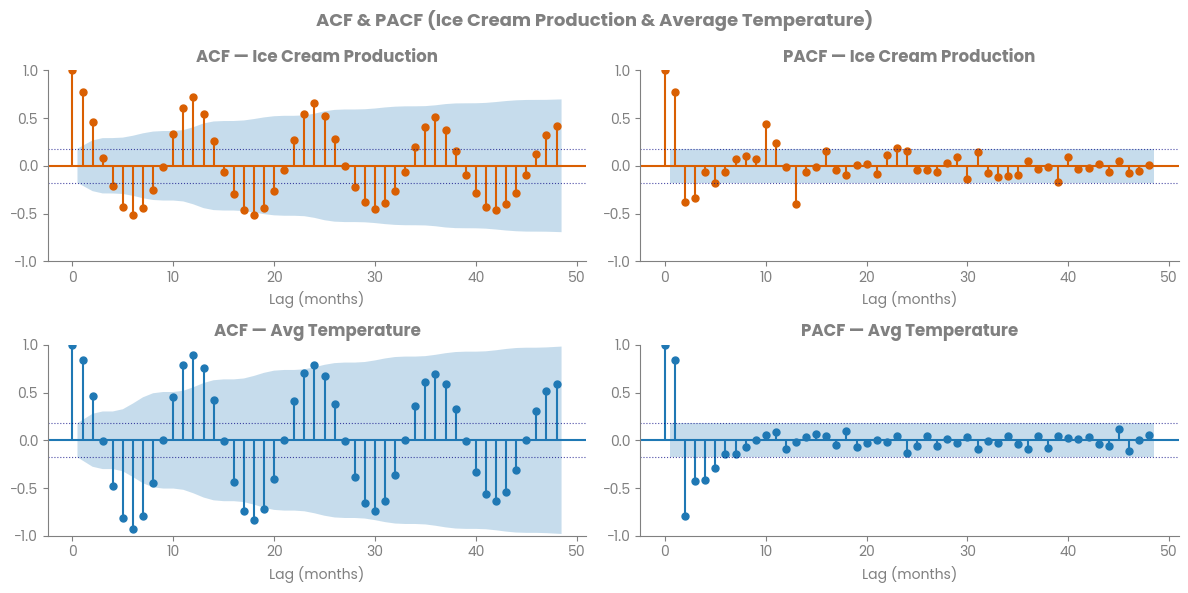

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(12,6))
fig.suptitle("ACF & PACF (Ice Cream Production & Average Temperature)", fontsize=13, fontweight="bold", color='#808080')

for row, (col, color) in enumerate([(CREAM, "#D95F02"), (TEMP, "#1F78B4")]):
    plot_acf(df[col].dropna(), lags=48, ax=axes[row, 0], color=color, vlines_kwargs={"colors": color}, title=f"ACF — {col}")
    plot_pacf(df[col].dropna(), lags=48, ax=axes[row, 1], color=color, vlines_kwargs={"colors": color}, title=f"PACF — {col}", method="ywm")

for ax in axes.flatten():
    ax.axhline( CONF, color="navy", lw=0.8, ls=":", alpha=0.7)
    ax.axhline(-CONF, color="navy", lw=0.8, ls=":", alpha=0.7)
    ax.set_xlabel("Lag (months)")

plt.tight_layout()
plt.show()

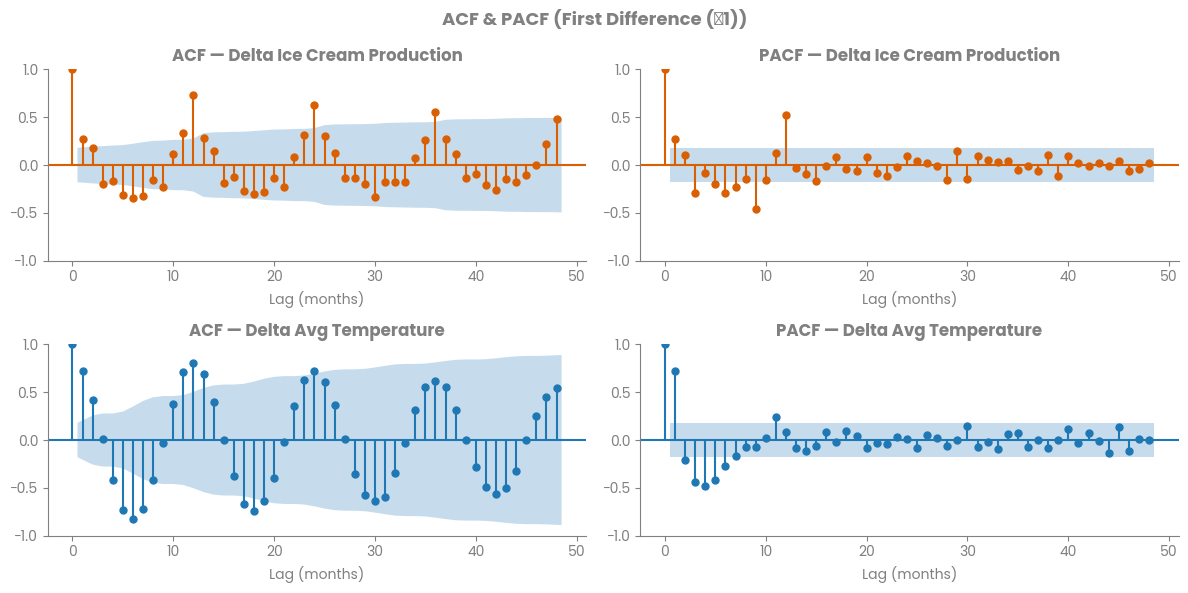

In [74]:
# ACF & PACF pada First Difference
fig, axes = plt.subplots(2, 2, figsize=(12,6))
fig.suptitle("ACF & PACF (First Difference (Δ1))", fontsize=13, fontweight="bold", color='#808080')

for row, (col, color) in enumerate([(CREAM, "#D95F02"), (TEMP, "#1F78B4")]):
    d1 = df[col].diff().dropna()
    plot_acf(d1, lags=48, ax=axes[row, 0], color=color, vlines_kwargs={"colors": color}, title=f"ACF — Delta {col}")
    plot_pacf(d1, lags=48, ax=axes[row, 1], color=color, vlines_kwargs={"colors": color}, title=f"PACF — Delta {col}", method="ywm")

for ax in axes.flatten():
    ax.set_xlabel("Lag (months)")

plt.tight_layout()
plt.show()

In [75]:
lags_acf  = 48
CONF      = 1.96 / np.sqrt(len(df))

print("ACF & PACF ANALYSIS (lags = 48 months)")
print(f"Confidence bound: ±{CONF:.4f}  (95%, n={len(df)})")

for col in [CREAM, TEMP]:
    series = df[col].dropna()
    acf_vals  = acf(series,  nlags=lags_acf, fft=True)
    pacf_vals = pacf(series, nlags=lags_acf, method="ywm")

    print(f"\n{'─'*65}")
    print(f"  {col}")
    print(f"{'─'*65}")

    # Full table
    print(f"\n  ACF & PACF per Lag:")
    print(f"    {'Lag':<6} {'ACF':>8} {'Sig?':>6}   {'PACF':>8} {'Sig?':>6}")
    for lag in range(1, lags_acf + 1):
        a_sig  = "✓" if abs(acf_vals[lag])  > CONF else "—"
        pa_sig = "✓" if abs(pacf_vals[lag]) > CONF else "—"
        print(f"    {lag:<6} {acf_vals[lag]:>8.3f} {a_sig:>6}   {pacf_vals[lag]:>8.3f} {pa_sig:>6}")

    # Significant Lags Summary
    sig_acf  = [l for l in range(1, lags_acf+1) if abs(acf_vals[l])  > CONF]
    sig_pacf = [l for l in range(1, lags_acf+1) if abs(pacf_vals[l]) > CONF]

    print(f"\n  Significant ACF  lags ({len(sig_acf)})  : {sig_acf}")
    print(f"  Significant PACF lags ({len(sig_pacf)}) : {sig_pacf}")

    # Seasonality Signature
    seasonal_lags = [12, 24, 36, 48]
    print(f"\n  Seasonal Signature (multiples of 12):")
    print(f"    {'Lag':<8} {'ACF':>8} {'Sig?':>6}   {'PACF':>8} {'Sig?':>6}")
    for l in seasonal_lags:
        if l <= lags_acf:
            print(f"    {l:<8} {acf_vals[l]:>8.3f}   {pacf_vals[l]:>8.3f}")

    # AR/MA Order Hint
    # AR order: last significant PACF lag (non-seasonal)
    sig_pacf_ns = [l for l in sig_pacf if l not in seasonal_lags]
    sig_acf_ns  = [l for l in sig_acf  if l not in seasonal_lags]
    ar_hint = max(sig_pacf_ns) if sig_pacf_ns else 0
    ma_hint = max(sig_acf_ns)  if sig_acf_ns  else 0

    # ACF decay pattern
    acf_early = [acf_vals[l] for l in range(1, 7)]
    if all(v > CONF for v in acf_early[:3]):
        decay = "slow decay → AR or mixed process"
    elif acf_vals[1] > CONF and acf_vals[2] < CONF:
        decay = "sharp cutoff at lag 1 → MA(1) candidate"
    else:
        decay = "mixed pattern"

    print(f"\n  Model Order Hints:")
    print(f"   - ACF  pattern : {decay}")
    print(f"   - Suggested AR order (p) : {ar_hint}  "
          f"(last significant non-seasonal PACF)")
    print(f"    Suggested MA order (q) : {ma_hint}  "
          f"(last significant non-seasonal ACF)")
    sig_seasonal_acf = [l for l in seasonal_lags if abs(acf_vals[l]) > CONF]
    if sig_seasonal_acf:
        print(f"    Seasonal component detected at lags: {sig_seasonal_acf} "
              f"→ consider SARIMA")

ACF & PACF ANALYSIS (lags = 48 months)
Confidence bound: ±0.1789  (95%, n=120)

─────────────────────────────────────────────────────────────────
  Ice Cream Production
─────────────────────────────────────────────────────────────────

  ACF & PACF per Lag:
    Lag         ACF   Sig?       PACF   Sig?
    1         0.777      ✓      0.777      ✓
    2         0.455      ✓     -0.375      ✓
    3         0.079      —     -0.340      ✓
    4        -0.214      ✓     -0.064      —
    5        -0.428      ✓     -0.179      ✓
    6        -0.511      ✓     -0.068      —
    7        -0.447      ✓      0.069      —
    8        -0.256      ✓      0.104      —
    9        -0.009      —      0.074      —
    10        0.330      ✓      0.440      ✓
    11        0.608      ✓      0.241      ✓
    12        0.722      ✓     -0.017      —
    13        0.544      ✓     -0.401      ✓
    14        0.259      ✓     -0.062      —
    15       -0.062      —     -0.009      —
    16       -0.292   

### Autocorrelation & Partial Autocorrelation Dynamics

To formally identify the underlying autoregressive and moving average components required for time series forecasting, an analysis of the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) was conducted over a 48-month lag window at a 95% confidence interval.

**Ice Cream Production**

The correlogram for the production series exhibits a prolonged, cyclical decay in the ACF, with 38 of the 48 evaluated lags remaining statistically significant. Most notably, strong positive correlations systematically reappear at exact multiples of 12 months, specifically at lags 12, 24, 36, and 48, providing definitive confirmation of an annual seasonal structure. Conversely, the PACF demonstrates a much sharper drop-off, with direct temporal influence fading significantly after the initial few months, save for residual spikes around the seasonal marks. This mixed pattern—a slowly dampening wave in the ACF paired with an abruptly truncated PACF—is highly characteristic of a process that requires both autoregressive terms to handle short-term momentum and seasonal differencing to address the recurring annual peaks.

**Average Temperature**

The temperature series presents a textbook sinusoidal autocorrelation signature, reflecting its highly deterministic meteorological nature. The ACF alternates seamlessly between distinct positive peaks at annual intervals and severe negative troughs at the six-month half-cycles, remaining highly significant across 40 lags. However, isolating the direct period-to-period influence via the PACF reveals a very sharp cutoff, with no statistically significant partial autocorrelations extending beyond the fifth month. This indicates that while the overarching seasonal cycle is dominant and long-lasting, the immediate autoregressive memory of the series is relatively short, cleanly resolving after a five-month historical window.

**Modeling Implications**

The profound seasonal signatures present in both datasets dictate that standard ARIMA architectures will be insufficient. The persistence and slow decay observed in the primary ACF plots further corroborate the presence of non-stationarity, signaling that standard first-order differencing, combined with seasonal differencing, will be necessary to achieve a stationary mean. Consequently, the transition into the predictive modeling phase will focus heavily on Seasonal Autoregressive Integrated Moving Average (SARIMA) methodologies to accurately map both the immediate temporal inertia and the rigid 12-month seasonal cycles.

## **Cross-Correlation Function**

The Cross-Correlation Function (CCF) quantifies the linear relationship between temperature at time t and ice cream production at time t + k, across a range of lags k. This is particularly relevant here given the hypothesized causal direction: temperature changes are expected to lead production decisions by some number of months, reflecting procurement cycles and manufacturing lead times. Bars exceeding the 95% confidence interval are highlighted to identify statistically significant lags. The strongest lag is confirmed with a dedicated scatter plot, with Pearson's r and its p-value annotated for reporting purposes.

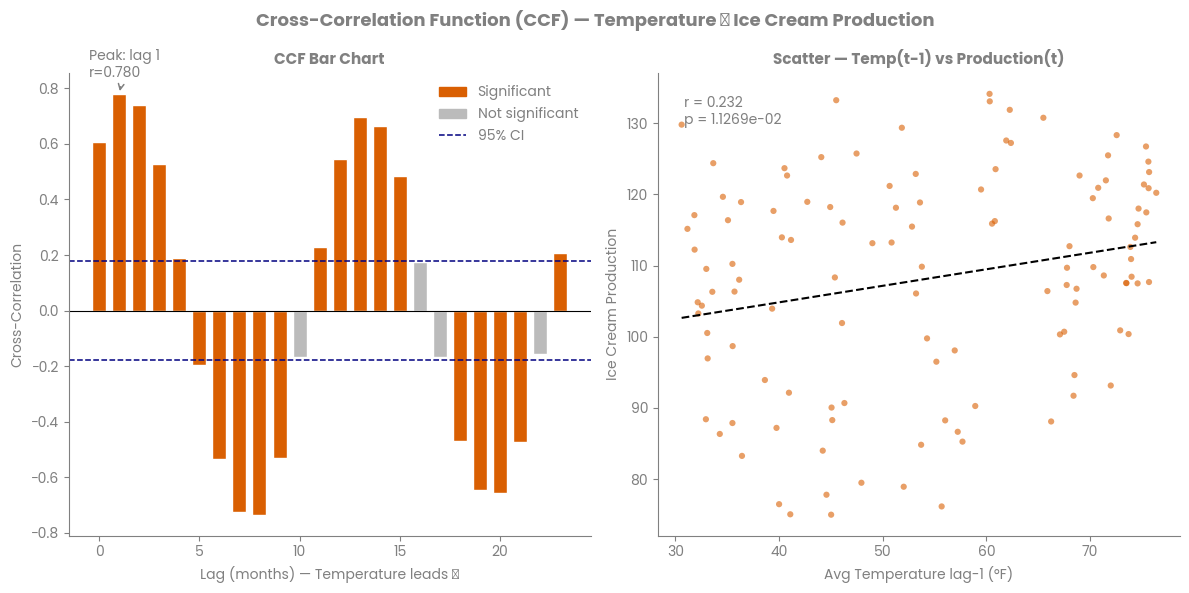


Strongest lag: Lag-1  |  r = 0.7805
      Significant lags (|CCF| > CI): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 18, 19, 20, 21, 23]


In [76]:
max_lag = 24
ccf_vals  = ccf(df[TEMP], df[CREAM], nlags=max_lag, unbiased=False)
lags_arr  = np.arange(len(ccf_vals))
sig_mask  = np.abs(ccf_vals) > CONF

fig, axes = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle("Cross-Correlation Function (CCF) — Temperature → Ice Cream Production", fontsize=13, fontweight="bold", color='#808080')

# Bar chart CCF
bar_colors = ["#D95F02" if s else "#BBBBBB" for s in sig_mask]
axes[0].bar(lags_arr, ccf_vals, color=bar_colors, width=0.7, edgecolor="white")
axes[0].axhline(CONF, color="navy", ls="--", lw=1.1, label="95% CI")
axes[0].axhline(-CONF, color="navy", ls="--", lw=1.1)
axes[0].axhline(0, color="black", lw=0.8)

best_lag = int(lags_arr[np.argmax(np.abs(ccf_vals))])
axes[0].annotate(f"Peak: lag {best_lag}\nr={ccf_vals[best_lag]:.3f}", xy=(best_lag, ccf_vals[best_lag]), xytext=(best_lag - 1.5, ccf_vals[best_lag] + 0.06), arrowprops=dict(arrowstyle="->", color="#808080", lw=1.1), fontsize=10, color="#808080")

orange_patch = mpatches.Patch(color="#D95F02", label="Significant")
grey_patch = mpatches.Patch(color="#BBBBBB", label="Not significant")
ci_line = plt.Line2D([0], [0], color="navy", ls="--", lw=1.1, label="95% CI")

axes[0].legend(handles=[orange_patch, grey_patch, ci_line], fontsize=10, frameon=False)
axes[0].set_xlabel("Lag (months) — Temperature leads →")
axes[0].set_ylabel("Cross-Correlation")
axes[0].set_title("CCF Bar Chart", fontsize=11)

# Scatter strongest lag
lag_best = best_lag
valid_lag = df[[CREAM]].assign(temp_lagged=df[TEMP].shift(lag_best)).dropna()
m_, b_, r_, p_, _ = stats.linregress(valid_lag["temp_lagged"], valid_lag[CREAM])
x_ = np.linspace(valid_lag["temp_lagged"].min(), valid_lag["temp_lagged"].max(), 100)
axes[1].scatter(valid_lag["temp_lagged"], valid_lag[CREAM], color="#D95F02", alpha=0.6, s=20, edgecolors="none")
axes[1].plot(x_, m_ * x_ + b_, color="black", lw=1.5, ls="--")
axes[1].set_xlabel(f"Avg Temperature lag-{lag_best} (°F)")
axes[1].set_ylabel(CREAM)
axes[1].set_title(f"Scatter — Temp(t-{lag_best}) vs Production(t)", fontsize=11)

axes[1].annotate(f"r = {r_:.3f}\np = {p_:.4e}", xy=(0.05, 0.95), xycoords="axes fraction", fontsize=10, verticalalignment="top", color='#808080')

plt.tight_layout()
plt.show()

print(f"\nStrongest lag: Lag-{best_lag}  |  r = {ccf_vals[best_lag]:.4f}")
print(f"      Significant lags (|CCF| > CI): {lags_arr[sig_mask].tolist()}")

In [77]:
max_lag  = 24
ccf_vals = ccf(df[TEMP], df[CREAM], nlags=max_lag, unbiased=False)
lags_arr = np.arange(len(ccf_vals))
sig_mask = np.abs(ccf_vals) > CONF

print("CROSS-CORRELATION FUNCTION (CCF)")
print("Temperature → Ice Cream Production")
print(f"Confidence bound: ±{CONF:.4f}  (95%, n={len(df)})")

# Full CCF Table
print(f"\n  CCF per Lag:")
print(f"    {'Lag':<8} {'CCF':>8} {'|CCF|':>8} {'Sig?':>6}")
for lag in lags_arr:
    sig = "Yes" if sig_mask[lag] else "No"
    print(f"    {lag:<8} {ccf_vals[lag]:>8.3f} {abs(ccf_vals[lag]):>8.3f} {sig:>6}")

# Significant Lags
sig_lags = lags_arr[sig_mask].tolist()
best_lag  = int(lags_arr[np.argmax(np.abs(ccf_vals))])

print(f"\n  Significant lags ({len(sig_lags)}) : {sig_lags}")
print(f"  Strongest lag            : Lag-{best_lag}  "
      f"(CCF = {ccf_vals[best_lag]:+.4f})")

# Scatter Stats
valid_lag = df[[CREAM]].assign(temp_lagged=df[TEMP].shift(best_lag)).dropna()
m, b, r, p, se = stats.linregress(valid_lag["temp_lagged"], valid_lag[CREAM])

print(f"\n  Regression — Temp(t-{best_lag}) → Production(t):")
print(f"  - {'Pearson r':<28} : {r:+.4f}")
print(f"  - {'R²':<28} : {r**2:.4f}  ({r**2*100:.1f}% variance explained)")
print(f"  - {'p-value':<28} : {p:.4e}  "
      f"({'significant' if p < 0.05 else 'not significant'})")
print(f"  - {'Slope':<28} : {m:+.4f}  (per 1°F increase)")
print(f"  - {'Intercept':<28} : {b:+.4f}")
print(f"  - {'Std Error':<28} : {se:.4f}")
print(f"  - {'n (valid pairs)':<28} : {len(valid_lag)}")

# Top Lags by CCF
top5 = sorted(range(len(ccf_vals)), key=lambda i: abs(ccf_vals[i]), reverse=True)[:5]

print(f"\n  Top 5 Lags by |CCF|:")
print(f"    {'Rank':<6} {'Lag':>6} {'CCF':>10} {'Sig?':>6}")
for rank, idx in enumerate(top5, 1):
    sig = "Yes" if sig_mask[idx] else "No"
    print(f"    {rank:<6} {idx:>6} {ccf_vals[idx]:>10.4f} {sig:>6}")

# Lead-lag Interpretation
print(f"\n  Interpretation:")
if best_lag == 0:
    print(f"    → Strongest relationship is contemporaneous (lag 0)")
elif best_lag > 0:
    print(f"    → Temperature leads Production by {best_lag} month(s)")
    print(f"       i.e. temp at t-{best_lag} best predicts ice cream at t")

if len(sig_lags) > 1:
    lag_range = max(sig_lags) - min(sig_lags)
    print(f"    → Signal persists across {len(sig_lags)} lags "
          f"(span: lag {min(sig_lags)}–{max(sig_lags)}, {lag_range} months wide)")

CROSS-CORRELATION FUNCTION (CCF)
Temperature → Ice Cream Production
Confidence bound: ±0.1789  (95%, n=120)

  CCF per Lag:
    Lag           CCF    |CCF|   Sig?
    0           0.606    0.606    Yes
    1           0.780    0.780    Yes
    2           0.742    0.742    Yes
    3           0.529    0.529    Yes
    4           0.188    0.188    Yes
    5          -0.197    0.197    Yes
    6          -0.536    0.536    Yes
    7          -0.727    0.727    Yes
    8          -0.735    0.735    Yes
    9          -0.530    0.530    Yes
    10         -0.166    0.166     No
    11          0.228    0.228    Yes
    12          0.547    0.547    Yes
    13          0.699    0.699    Yes
    14          0.667    0.667    Yes
    15          0.483    0.483    Yes
    16          0.175    0.175     No
    17         -0.168    0.168     No
    18         -0.470    0.470    Yes
    19         -0.648    0.648    Yes
    20         -0.658    0.658    Yes
    21         -0.472    0.472    Yes
  

### Cross-Correlation Analysis: Temperature as a Leading Indicator

To determine the delayed effect of weather patterns on manufacturing output, a Cross-Correlation Function (CCF) was evaluated to measure the alignment between average temperature and ice cream production across various temporal shifts. The analysis conclusively identifies temperature as a strong leading indicator for production. The maximum cross-correlation occurs precisely at a one-month lag (CCF = 0.780), indicating that shifts in climate historically precede corresponding shifts in production volume by exactly one month. This aligns with logical supply chain dynamics, where manufacturing schedules are rapidly adjusted based on immediate past weather trends to meet anticipated near-term consumer demand.

The CCF correlogram exhibits a pronounced, sinusoidal wave structure, seamlessly reflecting the synchronized annual seasonality of both datasets. Significant positive correlations are highly concentrated in the immediate short term (lags 1 and 2) and reliably reappear around the 12-to-14-month mark, echoing the repeating annual summer peaks. Conversely, strong negative correlations bottom out at lags 7 and 8, reaching a peak inverse relationship of -0.735. This negative trough captures the half-year meteorological cycle, perfectly illustrating how deep winter temperatures are diametrically opposed to peak summer production levels half a year later. Overall, 20 of the 23 evaluated lags demonstrated statistical significance, underscoring a deeply entrenched and reliable temporal relationship spanning multiple years.

To quantify this dynamic at the optimal temporal shift, a baseline linear regression was fitted mapping the previous month's temperature against current production. While the relationship is statistically significant (p = 0.011) with a positive slope indicating an expected increase of 0.23 production units per additional degree Fahrenheit, the baseline explanatory power of the unadjusted scatter remains modest, explaining roughly 5.4% of the absolute variance. This dynamic suggests that while temperature is highly effective at dictating the seasonal *timing* and *direction* of production shifts, the absolute *volume* of production is concurrently driven by the longer-term upward business trend identified in earlier rolling diagnostics.

Consequently, these findings validate the use of average temperature as an exogenous variable. By shifting the temperature data forward by one month, it can be integrated into a SARIMAX modeling architecture to accurately trigger the seasonal peaks and troughs, while the ARIMA components handle the underlying momentum and non-stationary trend.

# **Forecasting Modeling**

## **Train Test Split**

In [78]:
# Reserve the final 12 months (2024) as the hold-out test set.
# The remaining 108 months (2015–2023) form the training window.

TRAIN_END = "2023-12-31"
TEST_END  = "2024-12-31"

train = df.loc[:TRAIN_END]
test  = df.loc["2024-01-01":TEST_END]

print(f"Train : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} obs)")
print(f"Test  : {test.index.min().date()}  → {test.index.max().date()}   ({len(test)} obs)")

Train : 2015-01-01 → 2023-12-01  (108 obs)
Test  : 2024-01-01  → 2024-12-01   (12 obs)


## **Evaluate Helper**

In [79]:
def evaluate(actual, predicted, model_name, n_params=None, sigma2=None):
    """
    Compute RMSE, MAE, MAPE, and optionally AIC / BIC.

    Parameters
    ----------
    actual      : array-like, ground-truth values
    predicted   : array-like, model forecasts
    model_name  : str
    n_params    : int, number of estimated parameters (for AIC/BIC)
    sigma2      : float, residual variance from fitted model (for AIC/BIC)
    """
    actual    = np.array(actual)
    predicted = np.array(predicted)
    residuals = actual - predicted
    n         = len(actual)

    rmse = np.sqrt(np.mean(residuals ** 2))
    mae  = np.mean(np.abs(residuals))
    mape = np.mean(np.abs(residuals / actual)) * 100

    aic, bic = np.nan, np.nan
    if n_params is not None and sigma2 is not None and sigma2 > 0:
        log_lik = -0.5 * n * (np.log(2 * np.pi * sigma2) + 1)
        aic = -2 * log_lik + 2 * n_params
        bic = -2 * log_lik + n_params * np.log(n)

    return {
        "Model" : model_name,
        "RMSE"  : round(rmse, 4),
        "MAE"   : round(mae,  4),
        "MAPE"  : round(mape, 4),
        "AIC"   : round(aic,  4) if not np.isnan(aic) else "—",
        "BIC"   : round(bic,  4) if not np.isnan(bic) else "—",
    }


results_store = []   # collects all evaluation dicts for final comparison

## **Baseline Models**

Three benchmark forecasts are constructed before any parametric model is
fitted. Their purpose is to set a performance floor: any model that cannot
outperform these naive strategies does not justify its added complexity.

- **Naive (Random Walk)**: each forecast equals the last observed value.
  Appropriate when the series has a unit root and no drift.
- **Seasonal Naive**: each forecast equals the value from the same month
  one year prior. Given the dominant 12-month cycle identified in EDA,
  this is a strong and practically meaningful benchmark.
- **Mean**: each forecast equals the in-sample arithmetic mean. Tests
  whether any temporal structure is exploitable at all.

In [80]:
y_train = train[CREAM]
y_test  = test[CREAM]
h       = len(test)   # forecast horizon = 12 months

In [81]:
# Naive (last value)
naive_fc = np.full(h, y_train.iloc[-1])
results_store.append(evaluate(y_test, naive_fc, "Naive"))

In [82]:
# Seasonal Naive (same month, prior year)
seasonal_naive_fc = y_train.iloc[-12:].values   # last 12 months = template
results_store.append(evaluate(y_test, seasonal_naive_fc, "Seasonal Naive"))

In [83]:
# Mean
mean_fc = np.full(h, y_train.mean())
results_store.append(evaluate(y_test, mean_fc, "Mean"))

In [84]:
# Baseline summary
print(f"{'Model':<35} {'RMSE':>8} {'MAE':>8} {'MAPE':>8}")
for r in results_store:
    print(f"{r['Model']:<35} {r['RMSE']:>8.4f} {r['MAE']:>8.4f} {r['MAPE']:>8.2f}%")

Model                                   RMSE      MAE     MAPE
Naive                                29.8273  26.2326    22.42%
Seasonal Naive                        4.8202   4.2562     4.02%
Mean                                 14.4125  12.5545    11.77%


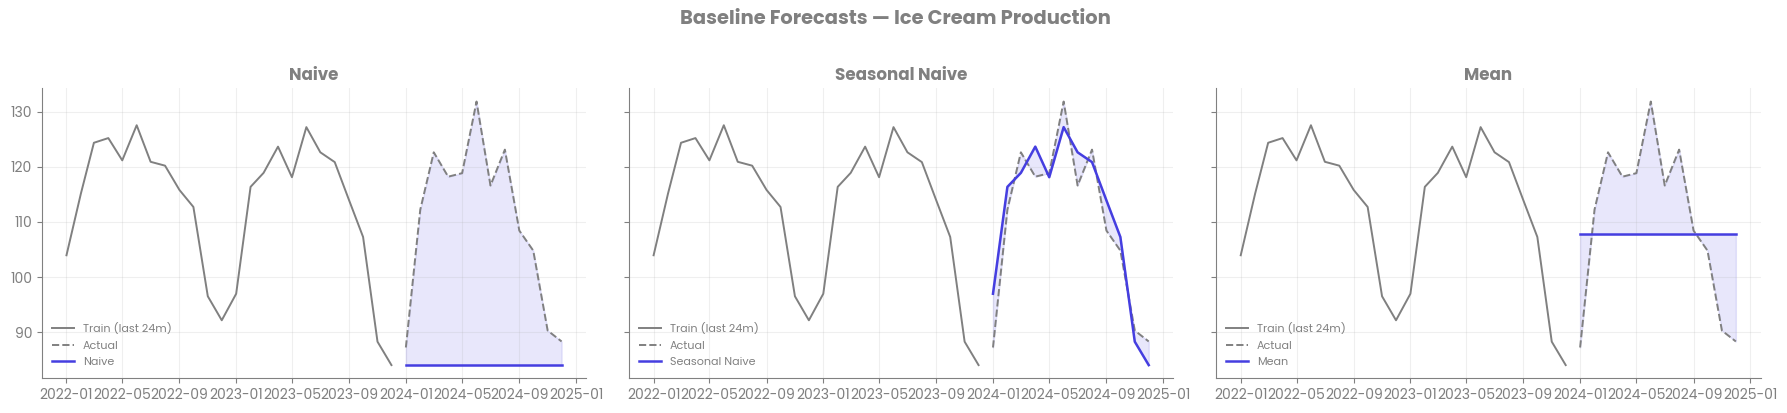

In [85]:
# Plot baselines
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
fig.suptitle("Baseline Forecasts — Ice Cream Production", fontsize=14, fontweight="bold", color="#808080", y=1.02)

baselines = [
    ("Naive",          naive_fc,          "#453ee0"),
    ("Seasonal Naive", seasonal_naive_fc, "#453ee0"),
    ("Mean",           mean_fc,           "#453ee0"),
]

for ax, (name, fc, color) in zip(axes, baselines):
    ax.plot(train.index[-24:], y_train.iloc[-24:], color="#808080", lw=1.4, label="Train (last 24m)")
    ax.plot(test.index, y_test, color="#808080", lw=1.4, ls="--", label="Actual")
    ax.plot(test.index, fc, color=color, lw=1.8, label=f"{name}")
    ax.fill_between(test.index, y_test, fc, alpha=0.12, color=color)
    ax.set_title(f"{name}", fontsize=12)
    ax.legend(fontsize=8, frameon=False)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## **Univariate Model: SARIMA**

The Seasonal ARIMA (SARIMA) model extends ARIMA with seasonal differencing and seasonal AR/MA terms, expressed as SARIMA(p, d, q)(P, D, Q)[s]. Based on the EDA findings:

- **s = 12** (monthly data, annual seasonality confirmed by ACF/lag plots)
- **D = 1** (seasonal differencing required; ADF/KPSS conflict on raw series was attributed to deterministic seasonality)
- **d = 0 or 1** (to be determined via grid search)

A two-stage grid search is performed:
1. A wide parameter sweep over `p, d, q ∈ {0, 1, 2}` and `P, Q ∈ {0, 1}` with `D = 1` fixed. Candidates are ranked by AIC on the training set.
2. The top-3 candidates are re-evaluated on the hold-out test set and ranked by RMSE for final model selection.

This approach balances in-sample fit quality (AIC) with out-of-sample
generalization (RMSE), guarding against overfitting.

In [86]:
# SARIMA — Grid Search
p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)
P_range = range(0, 2)
D_fixed = 1
Q_range = range(0, 2)
s       = 12

sarima_candidates = []

for p, d, q, P, Q in product(p_range, d_range, q_range, P_range, Q_range):
    order          = (p, d, q)
    seasonal_order = (P, D_fixed, Q, s)
    try:
        model = SARIMAX(y_train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        sarima_candidates.append({
            "order"          : order,
            "seasonal_order" : seasonal_order,
            "aic"            : model.aic,
            "bic"            : model.bic,
            "model"          : model,
        })
    except Exception:
        pass

sarima_candidates.sort(key=lambda x: x["aic"])

print(f"Total candidates fitted : {len(sarima_candidates)}")
print(f"\nTop 10 by AIC:")
print(f"{'Order':<18} {'Seasonal Order':<22} {'AIC':>10} {'BIC':>10}")
for c in sarima_candidates[:10]:
    print(
        f"{str(c['order']):<18} {str(c['seasonal_order']):<22} "
        f"{c['aic']:>10.2f} {c['bic']:>10.2f}"
    )

Total candidates fitted : 72

Top 10 by AIC:
Order              Seasonal Order                AIC        BIC
(0, 1, 2)          (0, 1, 1, 12)              459.30     468.83
(2, 1, 2)          (0, 1, 1, 12)              461.18     475.47
(1, 1, 2)          (0, 1, 1, 12)              461.22     473.13
(1, 0, 2)          (0, 1, 1, 12)              462.49     474.46
(2, 0, 2)          (0, 1, 1, 12)              464.48     478.85
(1, 1, 1)          (0, 1, 1, 12)              465.59     475.17
(0, 1, 1)          (0, 1, 1, 12)              465.67     472.85
(2, 0, 2)          (1, 1, 1, 12)              466.48     483.24
(2, 1, 1)          (0, 1, 1, 12)              467.59     479.57
(0, 1, 2)          (1, 1, 1, 12)              467.64     479.55


In [87]:
# Evaluate top-3 on test set
print(f"Test Set Evaluation — Top 3 Candidates:")
print(f"{'Model':<42} {'RMSE':>8} {'MAPE':>8}")

sarima_test_results = []
for c in sarima_candidates[:3]:
    fc_obj = c["model"].get_forecast(steps=h)
    fc_mean = fc_obj.predicted_mean.values
    ev = evaluate(y_test, fc_mean, f"SARIMA{c['order']}x{c['seasonal_order'][:3]}[12]", n_params=c["model"].df_model, sigma2=c["model"].scale)
    sarima_test_results.append((c, fc_mean, ev))
    print(f"{ev['Model']:<42} {ev['RMSE']:>8.4f} {ev['MAPE']:>8.2f}%")

# Best SARIMA by test RMSE
sarima_test_results.sort(key=lambda x: x[2]["RMSE"])
best_sarima_candidate, best_sarima_fc, best_sarima_ev = sarima_test_results[0]
best_sarima_model = best_sarima_candidate["model"]

results_store.append(best_sarima_ev)

print(f"\nBest SARIMA : {best_sarima_ev['Model']}")
print(f"RMSE = {best_sarima_ev['RMSE']}  |  AIC = {best_sarima_ev['AIC']}  |  BIC = {best_sarima_ev['BIC']}")

Test Set Evaluation — Top 3 Candidates:
Model                                          RMSE     MAPE
SARIMA(0, 1, 2)x(0, 1, 1)[12]                3.8920     3.11%
SARIMA(2, 1, 2)x(0, 1, 1)[12]                3.9547     3.16%
SARIMA(1, 1, 2)x(0, 1, 1)[12]                3.8174     3.04%

Best SARIMA : SARIMA(1, 1, 2)x(0, 1, 1)[12]
RMSE = 3.8174  |  AIC = 44.0545  |  BIC = 46.4791


A well-fitted model should leave residuals that resemble white noise: zero mean, constant variance, no autocorrelation, and approximate normality. Four standard diagnostics are applied: a residual time plot, a histogram with a fitted normal density, an ACF of the residuals, and the Ljung-Box portmanteau test. A significant Ljung-Box statistic (p < 0.05) at any lag indicates residual autocorrelation that the model has failed to capture.

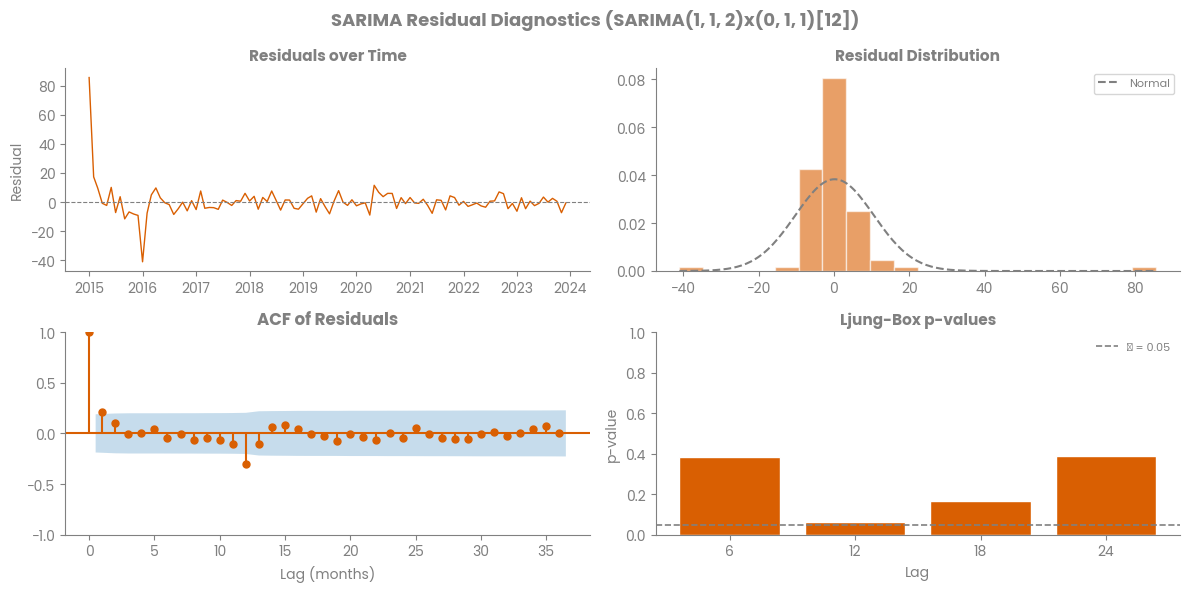


SARIMA Ljung-Box Test:
Lag         Statistic      p-value   White Noise?
6              6.3805       0.3819            Yes
12            20.3116       0.0614            Yes
18            23.6312       0.1675            Yes
24            25.3657       0.3861            Yes

Shapiro-Wilk normality test: p = 0.0000  (Non-normal)


In [88]:
resid_sarima = best_sarima_model.resid.dropna()
lb_sarima    = acorr_ljungbox(resid_sarima, lags=[6, 12, 18, 24], return_df=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle(f"SARIMA Residual Diagnostics ({best_sarima_ev['Model']})", fontsize=13, fontweight="bold", color="#808080")

# Time plot
axes[0, 0].plot(resid_sarima.index, resid_sarima.values, color="#D95F02", lw=1.0)
axes[0, 0].axhline(0, color="#808080", lw=0.8, ls="--")
axes[0, 0].set_title("Residuals over Time", fontsize=11)
axes[0, 0].set_ylabel("Residual")

# Histogram
axes[0, 1].hist(resid_sarima, bins=20, color="#D95F02", alpha=0.6, edgecolor="white", density=True)
xr = np.linspace(resid_sarima.min(), resid_sarima.max(), 200)
axes[0, 1].plot(xr, stats.norm.pdf(xr, resid_sarima.mean(), resid_sarima.std()), color="#808080", lw=1.5, ls="--", label="Normal")
axes[0, 1].set_title("Residual Distribution", fontsize=11)
axes[0, 1].legend(fontsize=8)

# ACF of residuals
plot_acf(resid_sarima, lags=36, ax=axes[1, 0], color="#D95F02", vlines_kwargs={"colors": "#D95F02"}, title="ACF of Residuals")
axes[1, 0].set_xlabel("Lag (months)")

# Ljung-Box p-values
axes[1, 1].bar(lb_sarima.index.astype(str), lb_sarima["lb_pvalue"], color=["#D95F02" if p > 0.05 else "#BBBBBB" for p in lb_sarima["lb_pvalue"]], edgecolor="white")
axes[1, 1].axhline(0.05, color="#808080", ls="--", lw=1.2, label="α = 0.05")
axes[1, 1].set_title("Ljung-Box p-values", fontsize=11)
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("p-value")
axes[1, 1].legend(fontsize=8, frameon=False)
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nSARIMA Ljung-Box Test:")
print(f"{'Lag':<8} {'Statistic':>12} {'p-value':>12} {'White Noise?':>14}")
for lag, row in lb_sarima.iterrows():
    wn = "Yes" if row["lb_pvalue"] > 0.05 else "No"
    print(f"{lag:<8} {row['lb_stat']:>12.4f} {row['lb_pvalue']:>12.4f} {wn:>14}")

# Normality test
_, p_norm_sarima = stats.shapiro(resid_sarima)
print(f"\nShapiro-Wilk normality test: p = {p_norm_sarima:.4f}  "
      f"({'Normal' if p_norm_sarima > 0.05 else 'Non-normal'})")

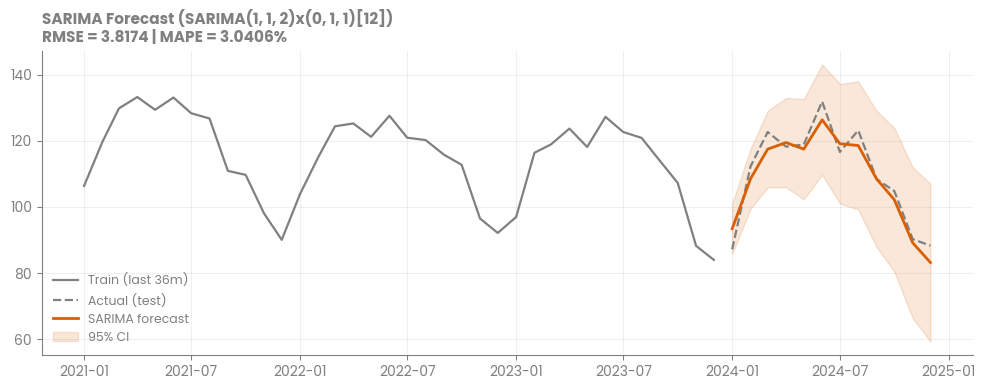

In [89]:
# SARIMA Forecast Plot
fc_obj_sarima = best_sarima_model.get_forecast(steps=h)
fc_mean_sarima = fc_obj_sarima.predicted_mean
fc_ci_sarima   = fc_obj_sarima.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train.index[-36:], y_train.iloc[-36:], color="#808080", lw=1.6, label="Train (last 36m)")
ax.plot(test.index, y_test, color="#808080", lw=1.6, ls="--", label="Actual (test)")
ax.plot(test.index, fc_mean_sarima, color="#D95F02", lw=2.0, label=f"SARIMA forecast")
ax.fill_between(test.index, fc_ci_sarima.iloc[:, 0], fc_ci_sarima.iloc[:, 1], alpha=0.15, color="#D95F02", label="95% CI")
ax.set_title(f"SARIMA Forecast ({best_sarima_ev['Model']})\n" f"RMSE = {best_sarima_ev['RMSE']} | MAPE = {best_sarima_ev['MAPE']}%", fontsize=11, loc="left")
ax.legend(fontsize=9, frameon=False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## **Multivariate with Temperature as Exogenous: SARIMAX**

SARIMAX extends SARIMA by allowing external regressors (exogenous variables) to enter the mean equation directly, without requiring them to be jointly modeled as a VAR system. Based on the CCF analysis in EDA, average temperature at lag 1 (i.e., the previous month's temperature) produced the strongest cross-correlation with ice cream production (CCF = 0.780). This lagged temperature variable is therefore constructed and used as the exogenous regressor.

The SARIMA order is inherited from the best-performing univariate specification identified in Section 2. This approach isolates the marginal contribution of the temperature signal by holding the autoregressive structure constant.

An additional candidate is also fitted using lag-0 (contemporaneous temperature) to directly test whether the prior-month or current-month temperature is the stronger predictor in a multivariate context.

In [90]:
# Construct exogenous regressors
df["Temp_Lag1"] = df[TEMP].shift(1)
df["Temp_Lag0"] = df[TEMP]

train_ex = df.loc[:TRAIN_END].dropna(subset=["Temp_Lag1"])
test_ex  = df.loc["2024-01-01":TEST_END]
y_train_ex = train_ex[CREAM]

exog_configs = {
    "Temp_Lag0": (train_ex[["Temp_Lag0"]], test_ex[["Temp_Lag0"]]),
    "Temp_Lag1": (train_ex[["Temp_Lag1"]], test_ex[["Temp_Lag1"]]),
}

best_order          = best_sarima_candidate["order"]
best_seasonal_order = best_sarima_candidate["seasonal_order"]

print("SARIMAX (Exogenous Temperature Variants)")
sarimax_results = {}

for exog_name, (exog_train, exog_test) in exog_configs.items():
    model = SARIMAX(y_train_ex, exog=exog_train, order=best_order, seasonal_order=best_seasonal_order, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

    fc_obj  = model.get_forecast(steps=h, exog=exog_test)
    fc_mean = fc_obj.predicted_mean.values
    fc_ci   = fc_obj.conf_int(alpha=0.05)

    ev = evaluate(y_test.values, fc_mean, f"SARIMAX({exog_name})", n_params=model.df_model, sigma2=model.scale)
    ev["AIC_fit"] = round(model.aic, 2)
    ev["BIC_fit"] = round(model.bic, 2)

    sarimax_results[exog_name] = {
        "model"   : model,
        "fc_mean" : fc_mean,
        "fc_ci"   : fc_ci,
        "ev"      : ev,
    }

    results_store.append(ev)

    print(f"\n{ev['Model']}:")
    print(f"- AIC (fit)  = {ev['AIC_fit']}")
    print(f"- BIC (fit)  = {ev['BIC_fit']}")
    print(f"- RMSE (test)= {ev['RMSE']}")
    print(f"- MAPE (test)= {ev['MAPE']}%")

    # Exogenous coefficient
    coef_name = exog_name
    if coef_name in model.params.index:
        coef  = model.params[coef_name]
        pval  = model.pvalues[coef_name]
        print(f"Exog coef ({coef_name}) = {coef:.4f}  (p = {pval:.4f}  " f"{'✓ significant' if pval < 0.05 else '✗ not significant'})")

SARIMAX (Exogenous Temperature Variants)

SARIMAX(Temp_Lag0):
- AIC (fit)  = 457.98
- BIC (fit)  = 472.2
- RMSE (test)= 3.7465
- MAPE (test)= 2.9908%
Exog coef (Temp_Lag0) = -0.1153  (p = 0.5145  ✗ not significant)

SARIMAX(Temp_Lag1):
- AIC (fit)  = 453.41
- BIC (fit)  = 467.63
- RMSE (test)= 4.244
- MAPE (test)= 3.3616%
Exog coef (Temp_Lag1) = 0.3766  (p = 0.0091  ✓ significant)


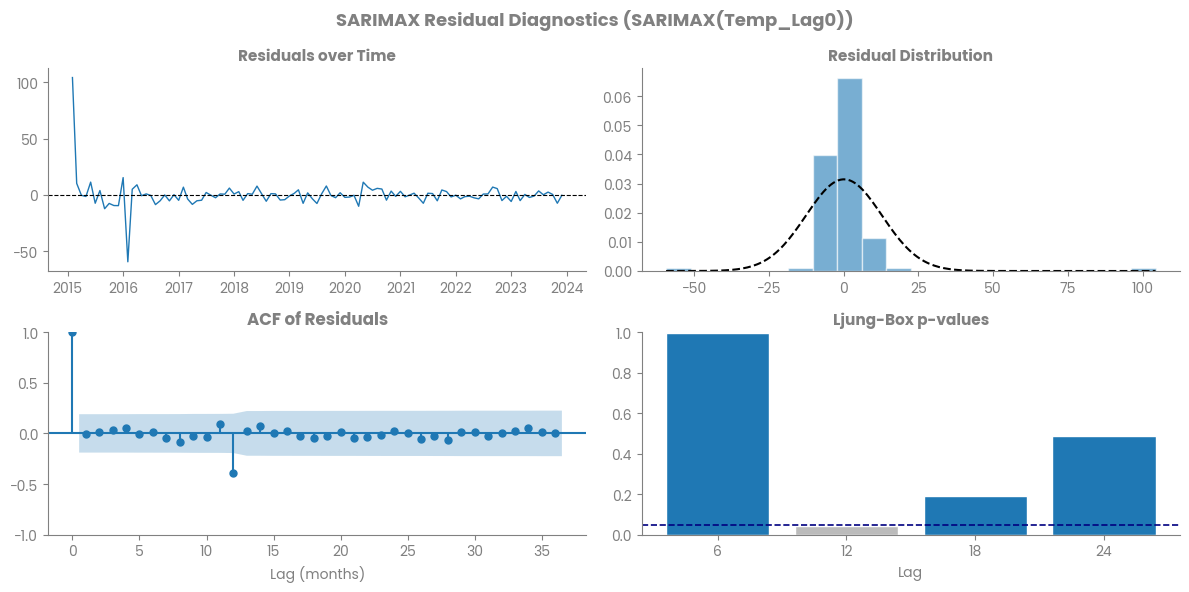


SARIMAX Ljung-Box Test:
Lag         Statistic      p-value   White Noise?
6              0.5469       0.9972            Yes
12            21.7057       0.0410             No
18            22.9239       0.1935            Yes
24            23.5189       0.4894            Yes

Shapiro-Wilk normality test: p = 0.0000  (Non-normal)


In [91]:
# SARIMAX Residual Diagnostics (best lag)
best_exog_name = min(sarimax_results, key=lambda k: sarimax_results[k]["ev"]["RMSE"])
best_sarimax   = sarimax_results[best_exog_name]

resid_sarimax = best_sarimax["model"].resid.dropna()
lb_sarimax    = acorr_ljungbox(resid_sarimax, lags=[6, 12, 18, 24], return_df=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle(f"SARIMAX Residual Diagnostics ({best_sarimax['ev']['Model']})", fontsize=13, fontweight="bold", color="#808080")

axes[0, 0].plot(resid_sarimax.index, resid_sarimax.values, color="#1F78B4", lw=1.0)
axes[0, 0].axhline(0, color="black", lw=0.8, ls="--")
axes[0, 0].set_title("Residuals over Time", fontsize=11)

axes[0, 1].hist(resid_sarimax, bins=20, color="#1F78B4", alpha=0.6, edgecolor="white", density=True)
xr = np.linspace(resid_sarimax.min(), resid_sarimax.max(), 200)
axes[0, 1].plot(xr, stats.norm.pdf(xr, resid_sarimax.mean(), resid_sarimax.std()), color="black", lw=1.5, ls="--")
axes[0, 1].set_title("Residual Distribution", fontsize=11)

plot_acf(resid_sarimax, lags=36, ax=axes[1, 0], color="#1F78B4", vlines_kwargs={"colors": "#1F78B4"}, title="ACF of Residuals")
axes[1, 0].set_xlabel("Lag (months)")

axes[1, 1].bar(lb_sarimax.index.astype(str), lb_sarimax["lb_pvalue"], color=["#1F78B4" if p > 0.05 else "#BBBBBB" for p in lb_sarimax["lb_pvalue"]], edgecolor="white")
axes[1, 1].axhline(0.05, color="navy", ls="--", lw=1.2)
axes[1, 1].set_title("Ljung-Box p-values", fontsize=11)
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nSARIMAX Ljung-Box Test:")
print(f"{'Lag':<8} {'Statistic':>12} {'p-value':>12} {'White Noise?':>14}")
for lag, row in lb_sarimax.iterrows():
    wn = "Yes" if row["lb_pvalue"] > 0.05 else "No"
    print(f"{lag:<8} {row['lb_stat']:>12.4f} {row['lb_pvalue']:>12.4f} {wn:>14}")

_, p_norm_sarimax = stats.shapiro(resid_sarimax)
print(f"\nShapiro-Wilk normality test: p = {p_norm_sarimax:.4f}  "
      f"({'Normal' if p_norm_sarimax > 0.05 else 'Non-normal'})")

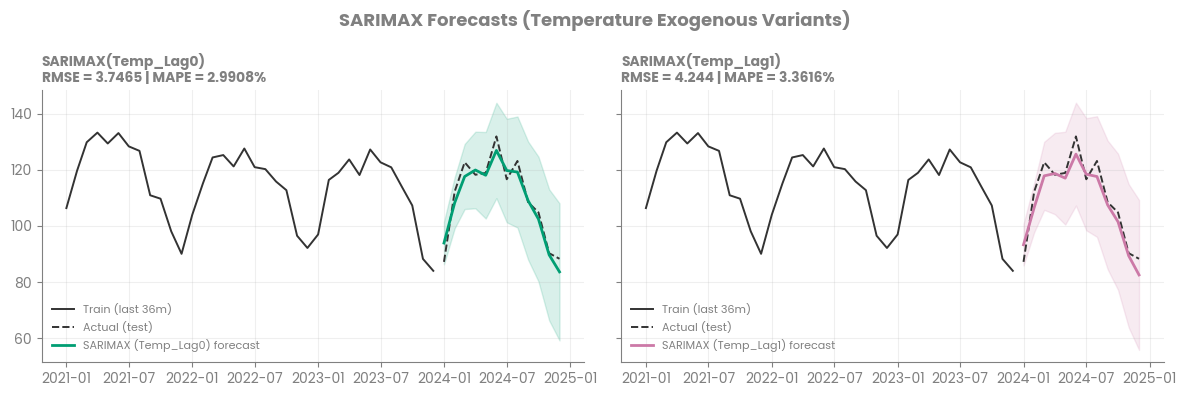

In [92]:
# SARIMAX Forecast Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig.suptitle("SARIMAX Forecasts (Temperature Exogenous Variants)", fontsize=13, fontweight="bold", color="#808080")

colors_sx = {"Temp_Lag0": "#009E73", "Temp_Lag1": "#CC79A7"}

for ax, (exog_name, res) in zip(axes, sarimax_results.items()):
    color = colors_sx[exog_name]
    ax.plot(train.index[-36:], y_train.iloc[-36:], color="#333333", lw=1.4, label="Train (last 36m)")
    ax.plot(test.index, y_test, color="#333333", lw=1.4, ls="--", label="Actual (test)")
    ax.plot(test.index, res["fc_mean"], color=color, lw=2.0, label=f"SARIMAX ({exog_name}) forecast")
    ax.fill_between(test.index, res["fc_ci"].iloc[:, 0], res["fc_ci"].iloc[:, 1], alpha=0.15, color=color)
    ax.set_title(f"{res['ev']['Model']}\nRMSE = {res['ev']['RMSE']} | MAPE = {res['ev']['MAPE']}%", fontsize=10, loc="left")
    ax.legend(fontsize=8, frameon=False)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## **Multivariate: Prophet**

Prophet, developed by Meta, decomposes the time series into trend, weekly seasonality, yearly seasonality, and holiday effects using a piecewise linear or logistic growth curve. It is particularly well-suited to data with strong multi-period seasonality and is robust to missing values and outliers.

Two variants are fitted:
- **Prophet (univariate)**: trend + yearly seasonality, no external regressors.
- **Prophet + Temperature**: the previous month's average temperature is added as an additional regressor, consistent with the lag-1 specification validated in both the CCF analysis and the SARIMAX section.

Prophet requires the dataframe to have columns `ds` (datetime) and `y` (target).

In [93]:
# Prepare Prophet dataframes
prophet_train = train.reset_index().rename(columns={"index": "ds", CREAM: "y"})
prophet_test  = test.reset_index().rename(columns={"index": "ds", CREAM: "y"})

prophet_train["ds"] = pd.to_datetime(prophet_train["ds"])
prophet_test["ds"]  = pd.to_datetime(prophet_test["ds"])

prophet_train["temp_lag1"] = df["Temp_Lag1"].loc[:TRAIN_END].values
prophet_train = prophet_train.dropna(subset=["temp_lag1"]).reset_index(drop=True)

temp_lag1_test = df["Temp_Lag1"].loc["2024-01-01":TEST_END].copy()
if temp_lag1_test.isna().any():
    temp_lag1_test.iloc[0] = df[TEMP].loc["2023-12-31"]
prophet_test["temp_lag1"] = temp_lag1_test.values

prophet_configs = {
    "Prophet (univariate)": {"use_regressor": False},
    "Prophet + Temp_Lag1" : {"use_regressor": True},
}

prophet_results = {}

for model_name, cfg in prophet_configs.items():
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_mode="additive", interval_width=0.95)

    if cfg["use_regressor"]:
        m.add_regressor("temp_lag1")
        m.fit(prophet_train[["ds", "y", "temp_lag1"]])
        future = prophet_test[["ds", "temp_lag1"]].copy()
    else:
        m.fit(prophet_train[["ds", "y"]])
        future = prophet_test[["ds"]].copy()

    forecast = m.predict(future)
    fc_mean  = forecast["yhat"].values
    fc_lower = forecast["yhat_lower"].values
    fc_upper = forecast["yhat_upper"].values

    ev = evaluate(y_test.values, fc_mean, model_name)
    prophet_results[model_name] = {
        "model"    : m,
        "forecast" : forecast,
        "fc_lower" : fc_lower,
        "fc_upper" : fc_upper,
        "ev"       : ev,
    }
    results_store.append(ev)

    print(f"  {model_name}")
    print(f"    RMSE = {ev['RMSE']}  |  MAPE = {ev['MAPE']}%\n")

  Prophet (univariate)
    RMSE = 5.5255  |  MAPE = 4.0318%

  Prophet + Temp_Lag1
    RMSE = 6.7509  |  MAPE = 5.284%



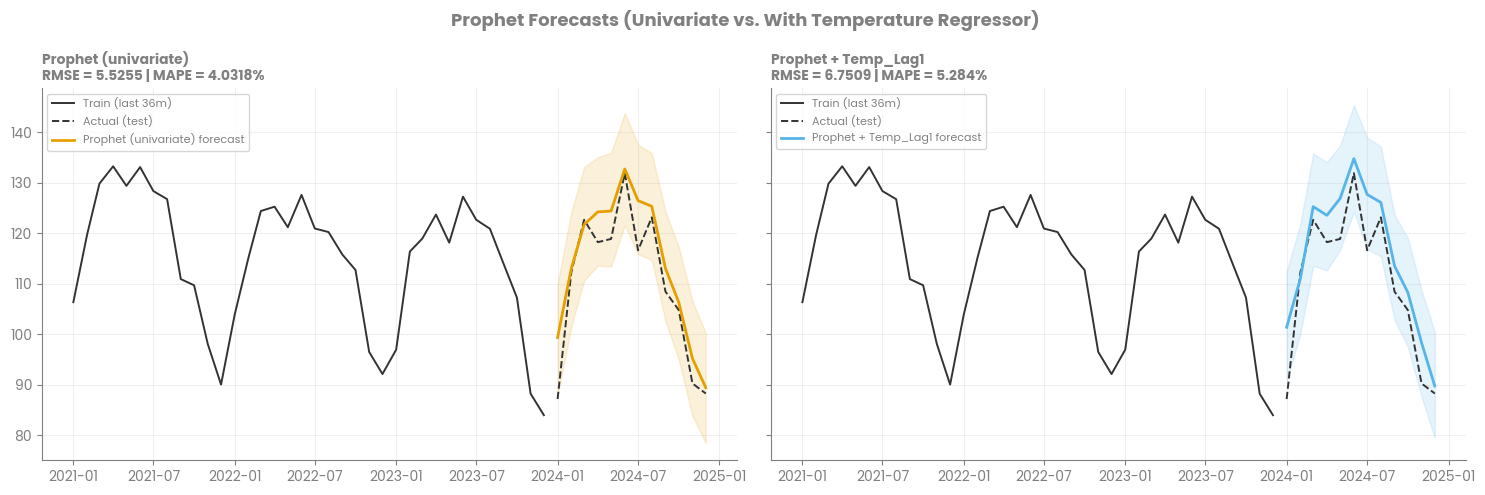

In [94]:
# Prophet Forecast Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle("Prophet Forecasts (Univariate vs. With Temperature Regressor)", fontsize=13, fontweight="bold", color="#808080")

colors_pr = {"Prophet (univariate)": "#E69F00", "Prophet + Temp_Lag1": "#56B4E9"}

for ax, (name, res) in zip(axes, prophet_results.items()):
    color = colors_pr[name]
    ax.plot(train.index[-36:], y_train.iloc[-36:], color="#333333", lw=1.4, label="Train (last 36m)")
    ax.plot(test.index, y_test, color="#333333", lw=1.4, ls="--", label="Actual (test)")
    ax.plot(test.index, res["forecast"]["yhat"].values, color=color, lw=2.0, label=f"{name} forecast")
    ax.fill_between(test.index, res["fc_lower"], res["fc_upper"], alpha=0.15, color=color)
    ax.set_title(f"{name}\nRMSE = {res['ev']['RMSE']} | MAPE = {res['ev']['MAPE']}%", fontsize=10, loc="left")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

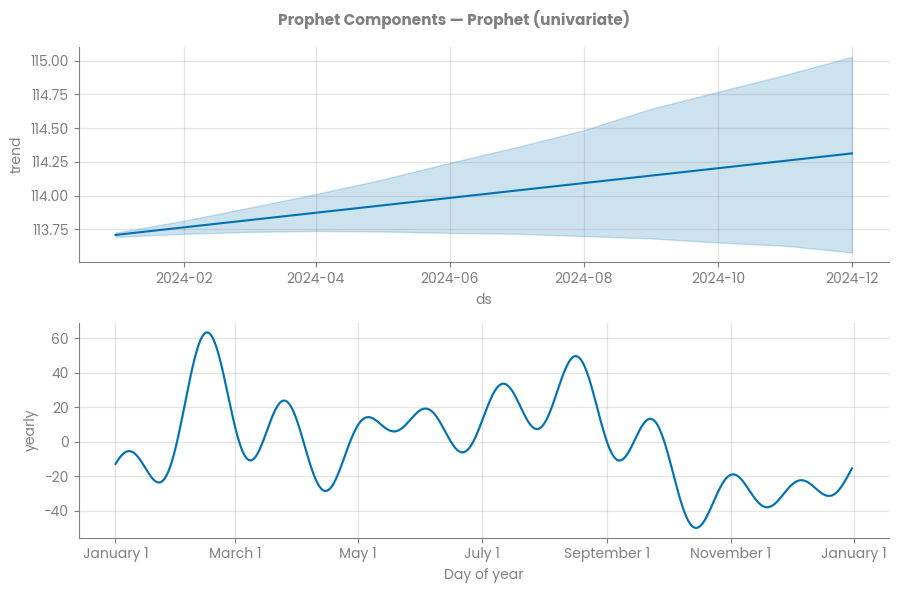

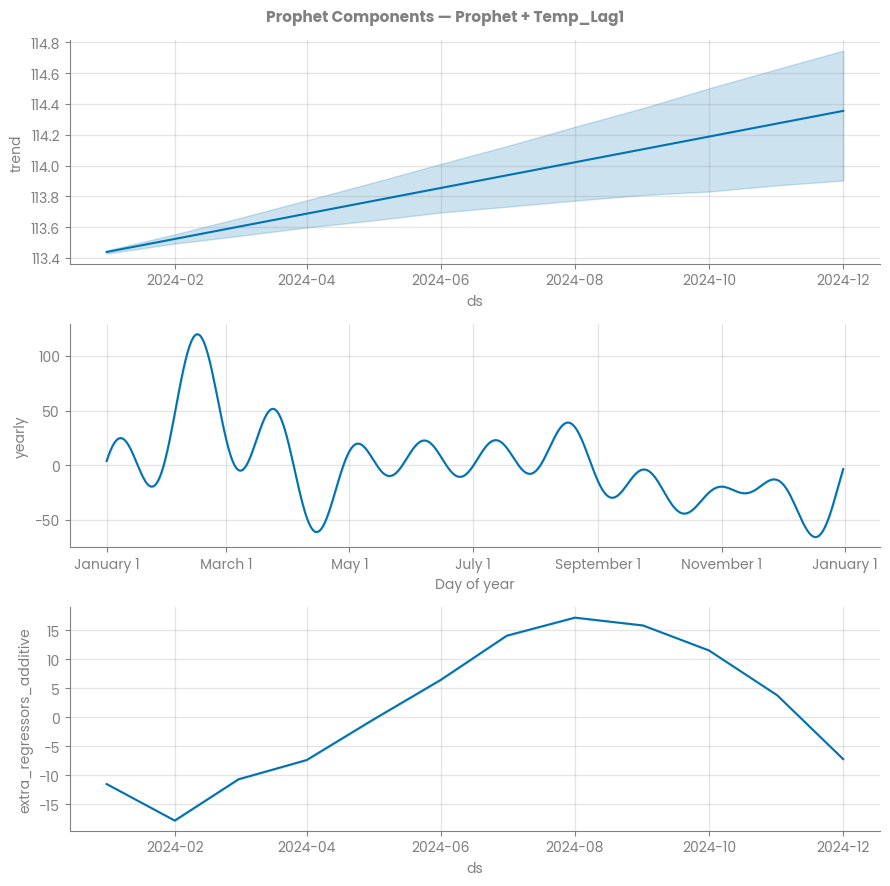

In [95]:
# Prophet component plots
for name, res in prophet_results.items():
    fig = res["model"].plot_components(res["forecast"])
    fig.suptitle(f"Prophet Components — {name}", fontsize=11,
                 fontweight="bold", color="#808080")
    plt.tight_layout()
    safe_name = name.replace(" ", "_").replace("+", "plus").replace("(", "").replace(")", "")
    plt.show()

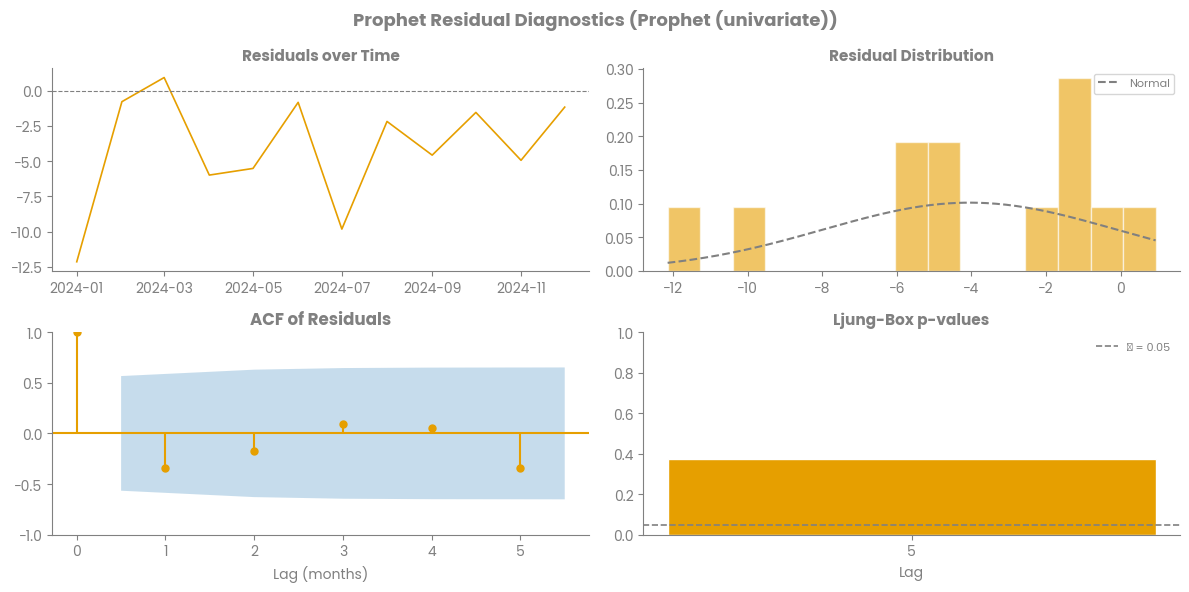


Prophet (Prophet (univariate)) — Ljung-Box Test:
Lag         Statistic      p-value   White Noise?
5              5.3456       0.3752            Yes

Shapiro-Wilk: p = 0.2362  (Normal)



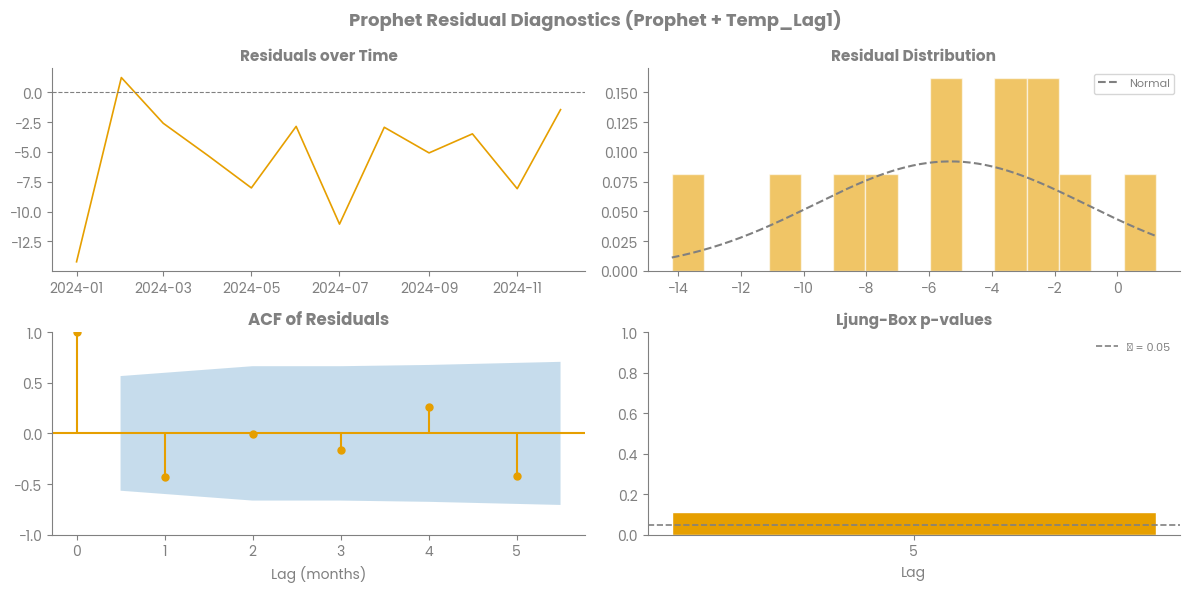


Prophet (Prophet + Temp_Lag1) — Ljung-Box Test:
Lag         Statistic      p-value   White Noise?
5              8.9415       0.1114            Yes

Shapiro-Wilk: p = 0.6127  (Normal)



In [96]:
# Prophet Residual Diagnostics
for name, res in prophet_results.items():
    resid_prophet = y_test.values - res["forecast"]["yhat"].values
    resid_s       = pd.Series(resid_prophet, index=test.index)
    max_lb_lag  = min(len(resid_s) // 2 - 1, 11)
    valid_lags  = [l for l in [6, 12, 18, 24] if l <= max_lb_lag]
    if not valid_lags:
        valid_lags = [max_lb_lag]
    lb_prophet  = acorr_ljungbox(resid_s, lags=valid_lags, return_df=True)

    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    fig.suptitle(f"Prophet Residual Diagnostics ({name})", fontsize=13, fontweight="bold", color="#808080")

    # Time plot
    axes[0, 0].plot(test.index, resid_s, color="#E69F00", lw=1.2)
    axes[0, 0].axhline(0, color="#808080", lw=0.8, ls="--")
    axes[0, 0].set_title("Residuals over Time", fontsize=11)

    # Histogram
    axes[0, 1].hist(resid_s, bins=15, color="#E69F00", alpha=0.6, edgecolor="white", density=True)
    xr = np.linspace(resid_s.min(), resid_s.max(), 200)
    axes[0, 1].plot(xr, stats.norm.pdf(xr, resid_s.mean(), resid_s.std()), color="#808080", lw=1.5, ls="--", label="Normal")
    axes[0, 1].set_title("Residual Distribution", fontsize=11)
    axes[0, 1].legend(fontsize=8)

    # ACF residuals
    plot_acf(resid_s, lags=min(11, len(resid_s)//2 - 1), ax=axes[1, 0], color="#E69F00", vlines_kwargs={"colors": "#E69F00"}, title="ACF of Residuals")
    axes[1, 0].set_xlabel("Lag (months)")

    # Ljung-Box
    axes[1, 1].bar(lb_prophet.index.astype(str), lb_prophet["lb_pvalue"], color=["#E69F00" if p > 0.05 else "#BBBBBB" for p in lb_prophet["lb_pvalue"]], edgecolor="white")
    axes[1, 1].axhline(0.05, color="#808080", ls="--", lw=1.2, label="α = 0.05")
    axes[1, 1].set_title("Ljung-Box p-values", fontsize=11)
    axes[1, 1].set_xlabel("Lag")
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].legend(fontsize=8, frameon=False)

    plt.tight_layout()
    safe_name = name.replace(" ", "_").replace("+", "plus").replace("(", "").replace(")", "")
    plt.show()

    # Print Ljung-Box & Shapiro
    print(f"\nProphet ({name}) — Ljung-Box Test:")
    print(f"{'Lag':<8} {'Statistic':>12} {'p-value':>12} {'White Noise?':>14}")
    for lag, row in lb_prophet.iterrows():
        wn = "Yes" if row["lb_pvalue"] > 0.05 else "No"
        print(f"{lag:<8} {row['lb_stat']:>12.4f} {row['lb_pvalue']:>12.4f} {wn:>14}")

    _, p_norm = stats.shapiro(resid_s)
    print(f"\nShapiro-Wilk: p = {p_norm:.4f}  "
          f"({'Normal' if p_norm > 0.05 else 'Non-normal'})\n")

## **Model Comparison & Selection**

All fitted models are ranked by their out-of-sample RMSE on the 12-month hold-out test set. Three additional metrics are reported to provide a multi-dimensional view of performance:

- **RMSE** (Root Mean Squared Error): penalizes large errors heavily; preferred when under-forecasting or over-forecasting peaks is costly.
- **MAE** (Mean Absolute Error): more robust to outliers than RMSE; measures average absolute deviation in index units.
- **MAPE** (Mean Absolute Percentage Error): scale-free; allows comparison across different series magnitudes.
- **AIC / BIC**: reported where available; penalizes model complexity and rewards parsimony on the training set.

The best model is selected based on the lowest test RMSE, subject to passing residual diagnostics (no significant autocorrelation in residuals at standard lags).

In [102]:
results_df = pd.DataFrame(results_store)
results_df = results_df.sort_values("RMSE").reset_index(drop=True)
results_df.index += 1   # rank from 1

print(f"  {'Rank':<6} {'Model':<42} {'RMSE':>8} {'MAE':>8} {'MAPE':>8}")
for rank, row in results_df.iterrows():
    marker = " (best)" if rank == 1 else ""
    print(f"  {rank:<6} {row['Model']:<42} {row['RMSE']:>8.4f} "
          f"{row['MAE']:>8.4f} {row['MAPE']:>8.2f}%{marker}")

best_model_name = results_df.iloc[0]["Model"]
print(f"\n  Selected model : {best_model_name}")

  Rank   Model                                          RMSE      MAE     MAPE
  1      SARIMAX(Temp_Lag0)                           3.7465   3.2108     2.99% (best)
  2      SARIMA(1, 1, 2)x(0, 1, 1)[12]                3.8174   3.2688     3.04%
  3      SARIMAX(Temp_Lag1)                           4.2440   3.6257     3.36%
  4      Seasonal Naive                               4.8202   4.2562     4.02%
  5      Prophet (univariate)                         5.5255   4.2003     4.03%
  6      Prophet + Temp_Lag1                          6.7509   5.5284     5.28%
  7      Mean                                        14.4125  12.5545    11.77%
  8      Naive                                       29.8273  26.2326    22.42%

  Selected model : SARIMAX(Temp_Lag0)


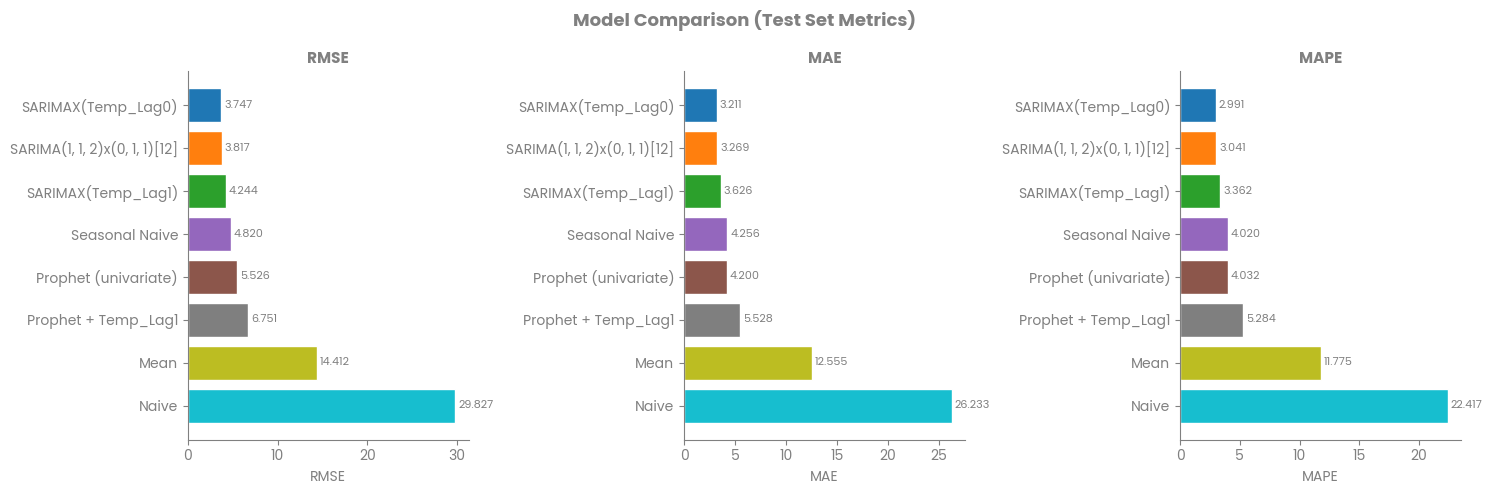

In [104]:
# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Comparison (Test Set Metrics)", fontsize=13, fontweight="bold", color="#808080")

palette = plt.cm.get_cmap("tab10", len(results_df))
colors  = [palette(i) for i in range(len(results_df))]

for ax, metric in zip(axes, ["RMSE", "MAE", "MAPE"]):
    vals   = results_df[metric].astype(float)
    labels = results_df["Model"]
    bars   = ax.barh(labels, vals, color=colors, edgecolor="white")
    ax.set_title(metric, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + vals.max() * 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=8, color='#808080')

plt.tight_layout()
plt.show()

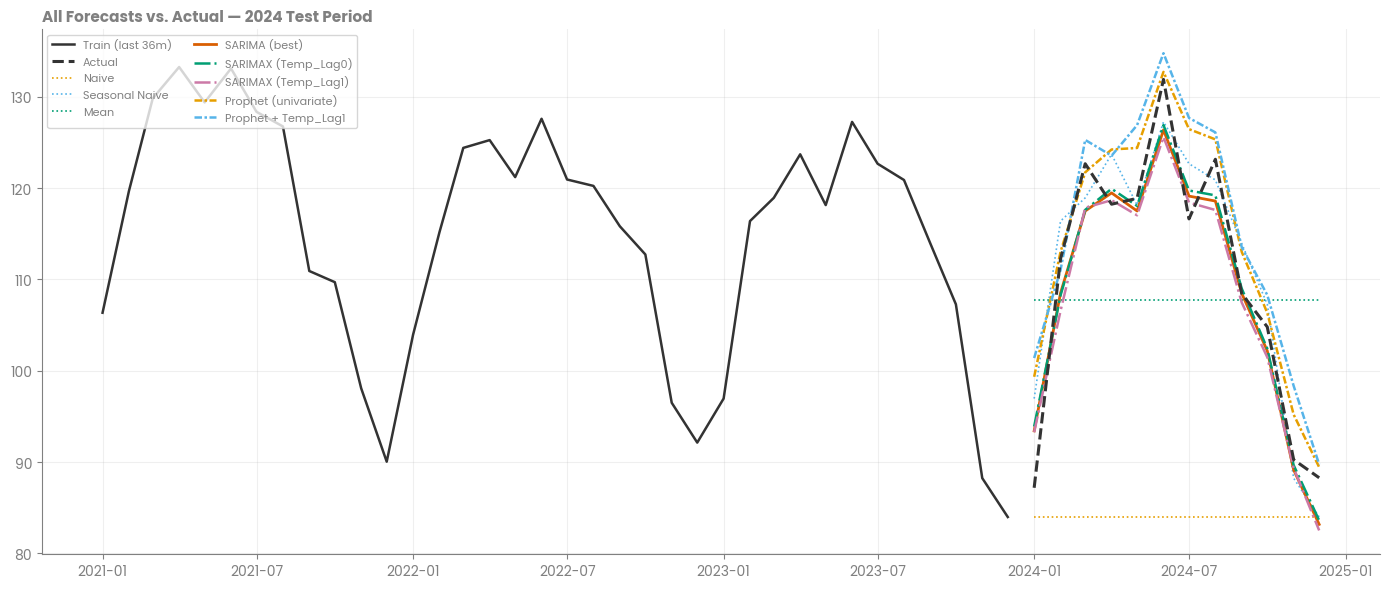

In [98]:
# All forecasts overlaid
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index[-36:], y_train.iloc[-36:], color="#333333", lw=1.8, label="Train (last 36m)", zorder=5)
ax.plot(test.index, y_test, color="#333333", lw=2.2, ls="--", label="Actual", zorder=6)

# Baselines
ax.plot(test.index, naive_fc,         color="#E69F00", lw=1.2, ls=":", label="Naive")
ax.plot(test.index, seasonal_naive_fc, color="#56B4E9", lw=1.2, ls=":", label="Seasonal Naive")
ax.plot(test.index, mean_fc,           color="#009E73", lw=1.2, ls=":", label="Mean")

# SARIMA
ax.plot(test.index, best_sarima_fc, color="#D95F02", lw=2.0, label=f"SARIMA (best)")

# SARIMAX
for exog_name, res in sarimax_results.items():
    color = colors_sx[exog_name]
    ax.plot(test.index, res["fc_mean"], color=color, lw=1.8, ls="-.", label=f"SARIMAX ({exog_name})")

# Prophet
for name, res in prophet_results.items():
    color = colors_pr[name]
    ax.plot(test.index, res["forecast"]["yhat"].values, color=color, lw=1.8, ls=(0, (3, 1, 1, 1)), label=name)

ax.set_title("All Forecasts vs. Actual — 2024 Test Period", fontsize=11, loc="left")
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## **Best Model**

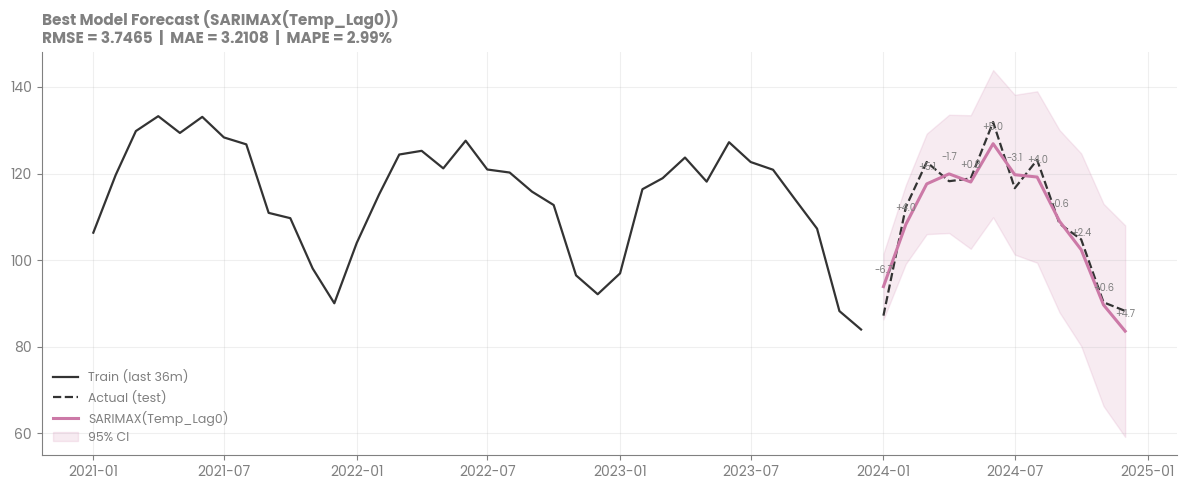

In [99]:
# Best Model Forecast Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(train.index[-36:], y_train.iloc[-36:], color="#333333", lw=1.6, label="Train (last 36m)")
ax.plot(test.index, y_test, color="#333333", lw=1.6, ls="--", label="Actual (test)")

if "SARIMA" in best_model_name and "SARIMAX" not in best_model_name:
    fc_best  = best_sarima_fc
    fc_ci    = best_sarima_model.get_forecast(steps=h).conf_int(alpha=0.05)
    ax.plot(test.index, fc_best, color="#D95F02", lw=2.2, label=best_model_name)
    ax.fill_between(test.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], alpha=0.15, color="#D95F02", label="95% CI")

elif "SARIMAX" in best_model_name:
    exog_key = "Temp_Lag1" if "Lag1" in best_model_name else "Temp_Lag0"
    res      = sarimax_results[exog_key]
    fc_ci    = res["model"].get_forecast(steps=h, exog=test_ex[[exog_key]]).conf_int(alpha=0.05)
    ax.plot(test.index, res["fc_mean"], color="#CC79A7", lw=2.2, label=best_model_name)
    ax.fill_between(test.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], alpha=0.15, color="#CC79A7", label="95% CI")

else:  # Prophet
    res = prophet_results[best_model_name]
    ax.plot(test.index, res["forecast"]["yhat"].values, color="#E69F00", lw=2.2, label=best_model_name)
    ax.fill_between(test.index, res["fc_lower"], res["fc_upper"], alpha=0.15, color="#E69F00", label="95% CI")

best_ev = results_df[results_df["Model"] == best_model_name].iloc[0]

if "SARIMA" in best_model_name and "SARIMAX" not in best_model_name:
    fc_vals = best_sarima_fc
elif "SARIMAX" in best_model_name:
    fc_vals = sarimax_results[exog_key]["fc_mean"]
else:
    fc_vals = prophet_results[best_model_name]["forecast"]["yhat"].values

for date, actual, pred in zip(test.index, y_test.values, fc_vals):
    err = actual - pred
    ax.annotate(f"{err:+.1f}", xy=(date, pred), xytext=(0, 10), textcoords="offset points", fontsize=7, color="#808080", ha="center")

ax.set_title(f"Best Model Forecast ({best_model_name})\n" f"RMSE = {best_ev['RMSE']}  |  MAE = {best_ev['MAE']}  |  MAPE = {float(best_ev['MAPE']):.2f}%", fontsize=11, loc="left")
ax.legend(fontsize=9, frameon=False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### **Interpretation & Coefficient Analysis**

To understand what the selected model has actually learned, the estimated parameters are examined in detail. For SARIMA-family models, each coefficient carries a concrete interpretation in the context of monthly ice cream production data.

Key quantities reported:
- **AR terms** (φ): the direct influence of past production values on the current period; values close to 1 indicate high persistence.
- **MA terms** (θ): the influence of past forecast errors on the current prediction.
- **Seasonal AR/MA terms**: capture annual carryover effects at lag-12
  multiples.
- **Exogenous coefficient** (if SARIMAX): the marginal change in the
  production index for each 1°F increase in the lagged temperature,
  holding all autoregressive dynamics constant.

The information criteria (AIC, BIC) and residual standard deviation are also reported as compact summaries of overall model quality.


In [105]:
# Determine which fitted model object is the best
if "SARIMA" in best_model_name and "SARIMAX" not in best_model_name:
    best_fitted = best_sarima_model
elif "SARIMAX" in best_model_name:
    exog_key    = "Temp_Lag1" if "Lag1" in best_model_name else "Temp_Lag0"
    best_fitted = sarimax_results[exog_key]["model"]
else:
    best_fitted = None   # Prophet — no statsmodels object

if best_fitted is not None:
    print(f"BEST MODEL COEFFICIENTS — {best_model_name}")

    print(f"\n  AIC = {best_fitted.aic:.2f}  |  BIC = {best_fitted.bic:.2f}")
    print(f"  Residual std = {best_fitted.resid.std():.4f}")
    print(f"  Log-likelihood = {best_fitted.llf:.2f}")

    print(f"\n  {'Parameter':<30} {'Coefficient':>12} {'Std Err':>10} " f"{'z-stat':>10} {'p-value':>10} {'Sig':>5}")

    for param, coef in best_fitted.params.items():
        se   = best_fitted.bse.get(param,   np.nan)
        z    = best_fitted.tvalues.get(param, np.nan)
        pval = best_fitted.pvalues.get(param, np.nan)
        sig  = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ("." if pval < 0.1 else "")))
        print(f"  {param:<30} {coef:>12.4f} {se:>10.4f} {z:>10.4f} {pval:>10.4f} {sig:>5}")

    print("\n  Significance codes: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1")

    # Narrative interpretation
    params = best_fitted.params
    ar_keys = [k for k in params.index if k.startswith("ar.L")]
    ma_keys = [k for k in params.index if k.startswith("ma.L")]
    sar_keys = [k for k in params.index if k.startswith("ar.S")]
    sma_keys = [k for k in params.index if k.startswith("ma.S")]
    exog_keys = [k for k in params.index if k not in ar_keys + ma_keys + sar_keys + sma_keys + ["sigma2", "intercept", "drift"]]

    print(f"\n  Interpretation Summary:")

    if ar_keys:
        ar1 = params.get("ar.L1", None)
    if ar1 is not None:
        abs_ar1 = abs(ar1)
        if abs_ar1 > 0.7:
            strength = "strong"
        elif abs_ar1 > 0.2:
            strength = "moderate"
        else:
            strength = "negligible"
        print(f"AR(1) = {ar1:.4f}: a 1-unit increase in production last month "
              f"is associated with a {ar1:.4f}-unit change this month, "
              f"reflecting {strength} short-term persistence.")

    if sar_keys:
        sar1 = params.get("ar.S.L12", None)
        if sar1 is not None:
            print(f"  Seasonal AR(L12) = {sar1:.4f}: production 12 months ago contributes "
                  f"a {sar1:.4f}-unit carryover to the current month, confirming a "
                  f"{'positive' if sar1 > 0 else 'dampening'} annual cycle.")

    for ek in exog_keys:
        coef = params[ek]
        pval = best_fitted.pvalues.get(ek, np.nan)
        print(f"  Exog ({ek}) = {coef:.4f}: each 1°F increase in the selected temperature "
              f"variable is associated with a {coef:.4f}-unit change in production "
              f"({'significant' if pval < 0.05 else 'not significant'} at α = 0.05).")
else:
    name = best_model_name
    res  = prophet_results[name]
    print(f"\nBest model is Prophet — no statsmodels parameter table.")
    print(f"  RMSE = {res['ev']['RMSE']}  |  MAPE = {res['ev']['MAPE']}%")
    print("  Refer to component plots for trend/seasonality breakdown.")

BEST MODEL COEFFICIENTS — SARIMAX(Temp_Lag0)

  AIC = 457.98  |  BIC = 472.20
  Residual std = 12.6860
  Log-likelihood = -222.99

  Parameter                       Coefficient    Std Err     z-stat    p-value   Sig
  Temp_Lag0                           -0.1153     0.1769    -0.6519     0.5145      
  ar.L1                                0.0047     0.3810     0.0124     0.9901      
  ma.L1                               -0.3446     0.3772    -0.9136     0.3609      
  ma.L2                                0.2897     0.1388     2.0867     0.0369     *
  ma.S.L12                            -1.0000  1377.7906    -0.0007     0.9994      
  sigma2                              13.3281 18365.0958     0.0007     0.9994      

  Significance codes: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1

  Interpretation Summary:
AR(1) = 0.0047: a 1-unit increase in production last month is associated with a 0.0047-unit change this month, reflecting negligible short-term persistence.
  Exog (Temp_Lag0) = -0.1

## **Final Summary**

The table below consolidates all model results. Models are ranked by out-of-sample RMSE. The best model advances to the Conclusion stage for forecast interpretation and recommendation.

In [101]:
print(f"{'Rank':<5} {'Model':<42} {'RMSE':>8} {'MAE':>8} {'MAPE (%)':>10}")

for rank, row in results_df.iterrows():
    marker = "  [SELECTED]" if rank == 1 else ""
    print(f"{rank:<5} {row['Model']:<42} {row['RMSE']:>8.4f} " f"{row['MAE']:>8.4f} {float(row['MAPE']):>10.2f}{marker}")

print(f"\nSelected model for Stage 6 (Conclusion): {best_model_name}")
print(f"Test period: {test.index.min().date()} → {test.index.max().date()} (n = {h} months)")

Rank  Model                                          RMSE      MAE   MAPE (%)
1     SARIMAX(Temp_Lag0)                           3.7465   3.2108       2.99  [SELECTED]
2     SARIMA(1, 1, 2)x(0, 1, 1)[12]                3.8174   3.2688       3.04
3     SARIMAX(Temp_Lag1)                           4.2440   3.6257       3.36
4     Seasonal Naive                               4.8202   4.2562       4.02
5     Prophet (univariate)                         5.5255   4.2003       4.03
6     Prophet + Temp_Lag1                          6.7509   5.5284       5.28
7     Mean                                        14.4125  12.5545      11.77
8     Naive                                       29.8273  26.2326      22.42

Selected model for Stage 6 (Conclusion): SARIMAX(Temp_Lag0)
Test period: 2024-01-01 → 2024-12-01 (n = 12 months)
